In [1]:
# =========================
# First of all, helper function
# =========================

import numpy as np
import pandas as pd

def clean_bool_or_nan(val):
    """
    Return:
    - True / False for valid labels
    - np.nan for missing values
    """
    if pd.isna(val):
        return np.nan

    if isinstance(val, bool):
        return val

    if isinstance(val, (int, float)):
        if val in (0, 1):
            return bool(val)

    val_str = str(val).strip().upper()

    if val_str in {"TRUE", "T", "YES", "Y", "1"}:
        return True
    if val_str in {"FALSE", "F", "NO", "N", "0"}:
        return False
    if val_str == "":
        return np.nan

    raise ValueError(f"Unexpected boolean value: {val}")


def clean_bool(val):
    if pd.isna(val):
        return np.nan

    if isinstance(val, bool):
        return val

    val_str = str(val).strip().lower()

    if val_str in {"true", "1", "yes", "y", "t"}:
        return True
    if val_str in {"false", "0", "no", "n", "f"}:
        return False

    raise ValueError(f"Unexpected boolean value: {val}")


# =========================
# 1.1.4. Add consensus category
# =========================
def assign_consensus_category(row):
    gt = row["ground_truth_consensus"]
    agent = row["assistant_consensus"]

    if gt and agent:
        return "Both Valid"
    elif (not gt) and agent:
        return "Agent Valid Only"
    elif gt and (not agent):
        return "GT Valid Only"
    elif (not gt) and (not agent):
        return "Neither Valid"
    else:
        return np.nan


In [ ]:
# Step 1. Standardize both rounds into rating-level tables

# 1.1 Convert round1 into a standard rating-level table
from pathlib import Path


# =========================
# 1.1.1. Input / output paths
# =========================

round1_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round1/phaseII_final_fix_63.10.xlsx"
)

round1_rating_output = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round1/round1_rating_level.csv"
)

# =========================
# 1.1.2. Load round 1 data
# =========================

round1_df = pd.read_excel(round1_file)
round1_df.head()

# =========================
# 1.1.3. Build rater rows
# =========================

def build_rater_rows(df: pd.DataFrame, physician_name: str, role: str) -> pd.DataFrame:
    gt_col = f"{physician_name}_ground_truth"
    agent_col = f"{physician_name}_agent"

    out = pd.DataFrame({
        "round": "round1",
        "hadm_id": df["hadm_id"].astype(str).str.strip(),
        "disease": df["disease"],
        "physician_name": physician_name,
        "ground_truth_text": df["ground truth"],
        "assistant_diagnosis_text": df["run1_agent_diagnosis"],
        "ground_truth_is_true": df[gt_col].apply(clean_bool_or_nan),
        "assistant_diagnosis_is_true": df[agent_col].apply(clean_bool_or_nan),
        "rater_role": role,
        "case_in_primary_overlap": role == "primary",
        "final_human_consensus_ground_truth": df["ground_truth_physician_decision"].apply(clean_bool_or_nan), # Three replicates.
        "final_human_consensus_assistant": df["agent_physician_decision"].apply(clean_bool_or_nan), # Three replicates.
        "agent_LLM_decision": df["agent_LLM_decision"].apply(clean_bool_or_nan), # Three replicates.
    })

    return out

# =========================
# 1.1.4. Build rating-level table
# =========================

julien_rows = build_rater_rows(round1_df, "Julien", "primary")
xuewei_rows = build_rater_rows(round1_df, "Xuewei", "primary")
jan_rows = build_rater_rows(round1_df, "Jan", "adjudicator")

round1_rating_level = pd.concat(
    [julien_rows, xuewei_rows, jan_rows],
    ignore_index=True
)

round1_rating_level.head(10)

# =========================
# 1.1.5. Mark Jan rows with missing ratings
# =========================
# Keep Jan rows even when missing, as requested.
# This preserves the adjudicator structure and avoids treating blanks as False.

round1_rating_level[
    round1_rating_level["physician_name"] == "Jan"
].head(10)


# =========================
# 1.1.6. Quick sanity checks
# =========================

print("Rows:", len(round1_rating_level))
print("Unique cases:", round1_rating_level["hadm_id"].nunique())

print("\nRows by physician:")
print(round1_rating_level["physician_name"].value_counts())

print("\nMissing counts:")
print(
    round1_rating_level[
        ["ground_truth_is_true", "assistant_diagnosis_is_true"]
    ].isna().sum()
)

print("\nJan rows with both ratings missing:")
jan_missing_both = round1_rating_level[
    (round1_rating_level["physician_name"] == "Jan") &
    (round1_rating_level["ground_truth_is_true"].isna()) &
    (round1_rating_level["assistant_diagnosis_is_true"].isna())
]
print(len(jan_missing_both))


# =========================
# 1.1.7. Optional: only rows with actual ratings
# =========================
# Useful for inter-rater agreement calculations later.

round1_rating_level_nonmissing = round1_rating_level[
    ~(
        round1_rating_level["ground_truth_is_true"].isna() &
        round1_rating_level["assistant_diagnosis_is_true"].isna()
    )
].copy()

print("Rows with at least one actual rating:", len(round1_rating_level_nonmissing))
round1_rating_level_nonmissing.head()



# =========================
# 1.1.8. Save
# =========================

round1_rating_output.parent.mkdir(parents=True, exist_ok=True)
round1_rating_level.to_csv(round1_rating_output, index=False, encoding="utf-8-sig")

print(f"Saved to: {round1_rating_output}")


In [ ]:
# 1.2 Round 2 physician evaluation
# decode_physician_results
from __future__ import annotations

import argparse
import hashlib
from pathlib import Path

import pandas as pd


# =========================
# 1.2.1. Set input / output paths
# =========================
# Labels in sample_ehr_summary_suplement_70_with_labels are inaccurate; do not use them.
source_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round2/sample_ehr_summary_suplement_70_with_labels.xlsx"
)


physician_files = [
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round2/physician_evaluation_results_Catharina_20260407_114336.xlsx"),
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round2/physician_evaluation_results_Jan_Clusmann_20260405_121607.xlsx"),
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round2/physician_evaluation_results_Julien_Vibert_20260403_181636.xlsx"),
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round2/physician_evaluation_results_Xuewei_Wu_20260408_212757.xlsx"),
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round2/physician_evaluation_results_Lino_Moehrmann_20260408_144026.xlsx"),
    Path("/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round2/physician_evaluation_results_Elena_M_hrmann_20260408_152309.xlsx"),
]

output_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round2/decoded_physician_results_round2.csv"
)

# =========================
# 1.2.2. Helper functions
# =========================

def stable_ab_mapping(hadm_id: str) -> dict[str, str]:
    digest = hashlib.sha256(str(hadm_id).encode("utf-8")).hexdigest()
    use_ground_truth_as_a = int(digest, 16) % 2 == 0
    if use_ground_truth_as_a:
        return {
            "A diagnosis": "ground_truth",
            "B diagnosis": "assistant_diagnosis",
        }
    return {
        "A diagnosis": "assistant_diagnosis",
        "B diagnosis": "ground_truth",
    }


def normalize_bool(value) -> bool:
    if pd.isna(value):
        return False
    return str(value).strip() in {"TRUE", "True", "true", "1"}


def infer_physician_name(row: pd.Series, source_file: Path) -> str:
    if "physician_name" in row and pd.notna(row["physician_name"]) and str(row["physician_name"]).strip():
        return str(row["physician_name"]).strip()
    if "physician_id" in row and pd.notna(row["physician_id"]) and str(row["physician_id"]).strip():
        return str(row["physician_id"]).strip()

    name = source_file.stem
    prefix = "physician_evaluation_results_"
    if name.startswith(prefix):
        remainder = name[len(prefix):]
        parts = remainder.split("_")
        if len(parts) >= 3 and parts[-1].isdigit() and parts[-2].isdigit():
            remainder = "_".join(parts[:-2])
        return remainder.replace("_", " ").strip()

    return source_file.stem


def decode_single_file(
    physician_file: Path,
    source_df: pd.DataFrame,
) -> pd.DataFrame:
    eval_df = pd.read_excel(physician_file)

    source_subset = source_df[
        [
            "hadm_id",
            "disease",
            "ground_truth",
            "run_1_assistant_diagnosis",
        ]
    ].copy()

    source_subset["hadm_id"] = source_subset["hadm_id"].astype(str).str.strip()
    eval_df["hadm_id"] = eval_df["hadm_id"].astype(str).str.strip()

    merged = eval_df.merge(
        source_subset,
        on="hadm_id",
        how="left",
        validate="many_to_one",
    )

    decoded_rows = []
    for _, row in merged.iterrows():
        physician_name = infer_physician_name(row, physician_file)
        slot_mapping = stable_ab_mapping(row["hadm_id"])

        a_text = row.get("A diagnosis", "")
        b_text = row.get("B diagnosis", "")
        a_true = normalize_bool(row.get("A is TRUE", False))
        b_true = normalize_bool(row.get("B is TRUE", False))

        if slot_mapping["A diagnosis"] == "ground_truth":
            ground_truth_text = a_text
            assistant_text = b_text
            ground_truth_true = a_true
            assistant_true = b_true
        else:
            ground_truth_text = b_text
            assistant_text = a_text
            ground_truth_true = b_true
            assistant_true = a_true

        decoded_rows.append(
            {
                "source_file": physician_file.name,
                "physician_name": physician_name,
                "hadm_id": row["hadm_id"],
                "case_group": row.get("case_group", ""),
                "disease": row.get("disease", ""),
                "slot_a_label": slot_mapping["A diagnosis"],
                "slot_b_label": slot_mapping["B diagnosis"],
                "slot_a_text": a_text,
                "slot_b_text": b_text,
                "slot_a_is_true": a_true,
                "slot_b_is_true": b_true,
                "ground_truth_text": ground_truth_text,
                "assistant_diagnosis_text": assistant_text,
                "ground_truth_is_true": ground_truth_true,
                "assistant_diagnosis_is_true": assistant_true,
                "physician_disease_single_choice": row.get("disease (single-choice)", ""),
                "physician_final_diagnosis": row.get("diagnosis", ""),
                "physician_reasoning": row.get("reasoning", ""),
                "note": row.get("Note (optional)", ""),
                "source_ground_truth": row.get("ground_truth", ""),
                "source_run_1_assistant_diagnosis": row.get("run_1_assistant_diagnosis", ""),
            }
        )

    return pd.DataFrame(decoded_rows)


# =========================
# 1.2.3. Run decoding
# =========================

source_df = pd.read_excel(source_file)

decoded_dfs = []
for physician_file in physician_files:
    decoded_df = decode_single_file(physician_file, source_df)
    decoded_dfs.append(decoded_df)

decoded_results = pd.concat(decoded_dfs, ignore_index=True)

decoded_results["round"] = "round2"
decoded_results["rater_role"] = "primary"
decoded_results["case_in_primary_overlap"] = decoded_results["case_group"].eq("x")
decoded_results["expected_n_raters"] = decoded_results["case_group"].map({
    "x": 6,
    "y": 3,
    "z": 3,
})

print("Decoded rows:", len(decoded_results))
print("Unique physicians:", decoded_results["physician_name"].nunique())
print("Unique cases:", decoded_results["hadm_id"].nunique())

decoded_results.head()

# =========================
# 1.2.4. Save output
# =========================

output_file.parent.mkdir(parents=True, exist_ok=True)
decoded_results.to_csv(output_file, index=False, encoding="utf-8-sig")


print(f"Saved to: {output_file}")

# =========================
# 1.2.5. sanity checks
# =========================

from pathlib import Path
from itertools import combinations

import pandas as pd
import numpy as np

decoded_csv = output_file

df = pd.read_csv(decoded_csv)
df.head()

print("Rows:", len(df))
print("Unique physicians:", df["physician_name"].nunique())
print("Unique cases:", df["hadm_id"].nunique())

print("\nPhysicians:")
print(df["physician_name"].value_counts())

print("\nCase groups:")
print(df["case_group"].value_counts())

print("\nDiseases:")
print(df["disease"].value_counts())






In [ ]:
# Step 2. Build case-level consensus separately for round1 and round2

# 2.1 Generate round1 case-level consensus.
'''
round1 不做 majority vote
直接使用 round1 文件里已经整理好的最终 physician consensus:
    ground_truth_physician_decision
    agent_physician_decision
'''

# =========================
# 2.1.1. Load round1 original file
# =========================
from pathlib import Path
import pandas as pd
import numpy as np

round1_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/physician_evaluation/round1/phaseII_final_fix_63.10.xlsx"
)

round1_case_level_output = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round1/round1_case_level_consensus.csv"
)

round1_df = pd.read_excel(round1_file)
round1_df.head()



# =========================
# 2.1.3. Build round1 case-level consensus
# =========================

round1_case_level_consensus = pd.DataFrame({
    "round": "round1",
    "hadm_id": round1_df["hadm_id"].astype(str).str.strip(),
    "disease": round1_df["disease"],
    "ground_truth_text": round1_df["ground truth"],
    "assistant_diagnosis_text": round1_df["run1_agent_diagnosis"],
    "ground_truth_consensus": round1_df["ground_truth_physician_decision"].apply(clean_bool_or_nan),
    "assistant_consensus": round1_df["agent_physician_decision"].apply(clean_bool_or_nan),
    "agent_LLM_decision": round1_df["agent_LLM_decision"].apply(clean_bool_or_nan),
    "n_primary_raters": 2,
    "adjudicator_available": (
        round1_df["Jan_ground_truth"].notna() | round1_df["Jan_agent"].notna()
    ),
})


# =========================
# 2.1.4. Add consensus category
# =========================

round1_case_level_consensus["consensus_category"] = round1_case_level_consensus.apply(
    assign_consensus_category,
    axis=1
)


# =========================
# 2.1.5. Optional: add disagreement/adjudication information
# This helps with later inter-rater summaries or supplementary tables.
# =========================

julien_gt = round1_df["Julien_ground_truth"].apply(clean_bool_or_nan)
xuewei_gt = round1_df["Xuewei_ground_truth"].apply(clean_bool_or_nan)

julien_agent = round1_df["Julien_agent"].apply(clean_bool_or_nan)
xuewei_agent = round1_df["Xuewei_agent"].apply(clean_bool_or_nan)

round1_case_level_consensus["primary_disagreement_ground_truth"] = (
    julien_gt != xuewei_gt
)

round1_case_level_consensus["primary_disagreement_assistant"] = (
    julien_agent != xuewei_agent
)

round1_case_level_consensus["primary_disagreement_any"] = (
    round1_case_level_consensus["primary_disagreement_ground_truth"] |
    round1_case_level_consensus["primary_disagreement_assistant"]
)


# =========================
# 2.1.6. Quick checks
# =========================
print("Rows:", len(round1_case_level_consensus))
print("Unique cases:", round1_case_level_consensus["hadm_id"].nunique())

print("\nConsensus category counts:")
print(round1_case_level_consensus["consensus_category"].value_counts(dropna=False))

print("\nAdjudicator involved:")
print(round1_case_level_consensus["adjudicator_available"].value_counts(dropna=False))

print("\nPrimary disagreement (any):")
print(round1_case_level_consensus["primary_disagreement_any"].value_counts(dropna=False))


round1_case_level_consensus.head(10)


# =========================
# 2.1.7. Save as CSV
# =========================
round1_case_level_output.parent.mkdir(parents=True, exist_ok=True)
round1_case_level_consensus.to_csv(
    round1_case_level_output,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved to: {round1_case_level_output}")



In [ ]:
# 2.2 Generate round2 case-level consensus.

import pandas as pd
import numpy as np
from pathlib import Path

# 2.2.1 load round2_df
round2_csv = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round2/decoded_physician_results_round2.csv"
)

round2_df = pd.read_csv(round2_csv)


round2_df["ground_truth_is_true"] = round2_df["ground_truth_is_true"].apply(clean_bool)
round2_df["assistant_diagnosis_is_true"] = round2_df["assistant_diagnosis_is_true"].apply(clean_bool)

round2_df[
    ["ground_truth_is_true", "assistant_diagnosis_is_true"]
].dtypes


# 2.2.2 Define the majority-vote function
'''
这里默认采用简单多数：

6 个 physician 时：至少 4 票算 True
3 个 physician 时：至少 2 票算 True
也就是 sum(True votes) > n/2
'''

def majority_vote(series):
    valid = series.dropna().astype(bool)
    n = len(valid)

    if n == 0:
        return np.nan

    true_votes = valid.sum()
    return true_votes > (n / 2)


# 2.2.3 Generate round2 case-level consensus

round2_case_level_consensus = (
    round2_df.groupby(["hadm_id", "case_group", "disease"], as_index=False)
    .agg(
        round=("round", "first"),
        ground_truth_text=("ground_truth_text", "first"),
        assistant_diagnosis_text=("assistant_diagnosis_text", "first"),
        case_in_primary_overlap=("case_in_primary_overlap", "first"),
        expected_n_raters=("expected_n_raters", "first"),
        n_raters=("physician_name", "nunique"),
        ground_truth_votes_true=("ground_truth_is_true", lambda x: x.astype(bool).sum()),
        assistant_votes_true=("assistant_diagnosis_is_true", lambda x: x.astype(bool).sum()),
        ground_truth_consensus=("ground_truth_is_true", majority_vote),
        assistant_consensus=("assistant_diagnosis_is_true", majority_vote),
    )
)

round2_case_level_consensus.head()

# 2.2.4 Add four-category results
round2_case_level_consensus["consensus_category"] = round2_case_level_consensus.apply(
    assign_consensus_category,
    axis=1
)

round2_case_level_consensus.head()


# 2.2.5 Data checks
# Confirm the grouping and vote counts are correct

print("Rows:", len(round2_case_level_consensus))
print("Unique cases:", round2_case_level_consensus["hadm_id"].nunique())

print("\nCase groups:")
print(round2_case_level_consensus["case_group"].value_counts())

print("\nExpected raters vs observed raters:")
print(
    round2_case_level_consensus[
        ["hadm_id", "case_group", "expected_n_raters", "n_raters"]
    ].head(20)
)

# Check for missing values or mismatches: an empty table indicates good data integrity.
round2_case_level_consensus[
    round2_case_level_consensus["n_raters"] != round2_case_level_consensus["expected_n_raters"]
]


# 2.2.6 Inspect the four-category distribution
round2_case_level_consensus["consensus_category"].value_counts(dropna=False)


# 2.2.7 Save CSV
round2_case_level_output = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round2/round2_case_level_consensus.csv"
)

round2_case_level_output.parent.mkdir(parents=True, exist_ok=True)
round2_case_level_consensus.to_csv(
    round2_case_level_output,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved to: {round2_case_level_output}")


# 2.2.8 Add the corresponding round2 agent_LLM_decision values
round2_source_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/63/63.10/multi_run_combined.csv"
)

round2_case_level_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round2/round2_case_level_consensus.csv"
)

round2_source_df = pd.read_csv(round2_source_file)
round2_case_level_consensus = pd.read_csv(round2_case_level_file)

# Keep only required columns
round2_llm = round2_source_df[["hadm_id", "run_1_decision"]].copy()

round2_llm["hadm_id"] = round2_llm["hadm_id"].astype(str).str.strip()
round2_llm["agent_LLM_decision"] = round2_llm["run_1_decision"].apply(clean_bool)

round2_llm = round2_llm.drop(columns=["run_1_decision"])
round2_llm.head()

round2_case_level_consensus["hadm_id"] = (
    round2_case_level_consensus["hadm_id"].astype(str).str.strip()
)

round2_case_level_consensus = round2_case_level_consensus.merge(
    round2_llm,
    on="hadm_id",
    how="left",
    validate="one_to_one",
)

round2_case_level_consensus.head()

# Check whether the operation succeeded
print("Rows:", len(round2_case_level_consensus))
print("Missing agent_LLM_decision:", round2_case_level_consensus["agent_LLM_decision"].isna().sum())

# Save back to CSV
round2_case_level_consensus.to_csv(
    round2_case_level_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"Updated: {round2_case_level_file}")


In [ ]:
# Combine case-level consensus tables

from pathlib import Path
import pandas as pd
import numpy as np


round1_case_level_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round1/round1_case_level_consensus.csv"
)

round2_case_level_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round2/round2_case_level_consensus.csv"
)

output_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/all_rounds_case_level_consensus.csv"
)

round1_case_level = pd.read_csv(round1_case_level_file)
round2_case_level = pd.read_csv(round2_case_level_file)


# Optional: standardize hadm_id as string
round1_case_level["hadm_id"] = round1_case_level["hadm_id"].astype(str).str.strip()
round2_case_level["hadm_id"] = round2_case_level["hadm_id"].astype(str).str.strip()

# Build unified column set
all_columns = sorted(set(round1_case_level.columns).union(set(round2_case_level.columns)))

round1_case_level_aligned = round1_case_level.reindex(columns=all_columns)
round2_case_level_aligned = round2_case_level.reindex(columns=all_columns)


all_rounds_case_level_consensus = pd.concat(
    [round1_case_level_aligned, round2_case_level_aligned],
    ignore_index=True
)

# Optional: reorder columns for readability
preferred_order = [
    "round",
    "hadm_id",
    "case_group",
    "disease",
    "ground_truth_text",
    "assistant_diagnosis_text",
    "ground_truth_consensus",
    "assistant_consensus",
    "consensus_category",
    "agent_LLM_decision",
    "n_primary_raters",
    "adjudicator_available",
    "primary_disagreement_ground_truth",
    "primary_disagreement_assistant",
    "primary_disagreement_any",
    "case_in_primary_overlap",
    "expected_n_raters",
    "n_raters",
    "ground_truth_votes_true",
    "assistant_votes_true",
]

remaining_cols = [c for c in all_rounds_case_level_consensus.columns if c not in preferred_order]
all_rounds_case_level_consensus = all_rounds_case_level_consensus[
    [c for c in preferred_order if c in all_rounds_case_level_consensus.columns] + remaining_cols
]

# Quick checks
print("Total rows:", len(all_rounds_case_level_consensus))
print("\nRows by round:")
print(all_rounds_case_level_consensus["round"].value_counts())

print("\nMissing agent_LLM_decision:")
print(all_rounds_case_level_consensus["agent_LLM_decision"].isna().sum())

print("\nConsensus category counts:")
print(all_rounds_case_level_consensus["consensus_category"].value_counts(dropna=False))

all_rounds_case_level_consensus.head()


output_file.parent.mkdir(parents=True, exist_ok=True)
all_rounds_case_level_consensus.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig"
)

print(f"Saved to: {output_file}")




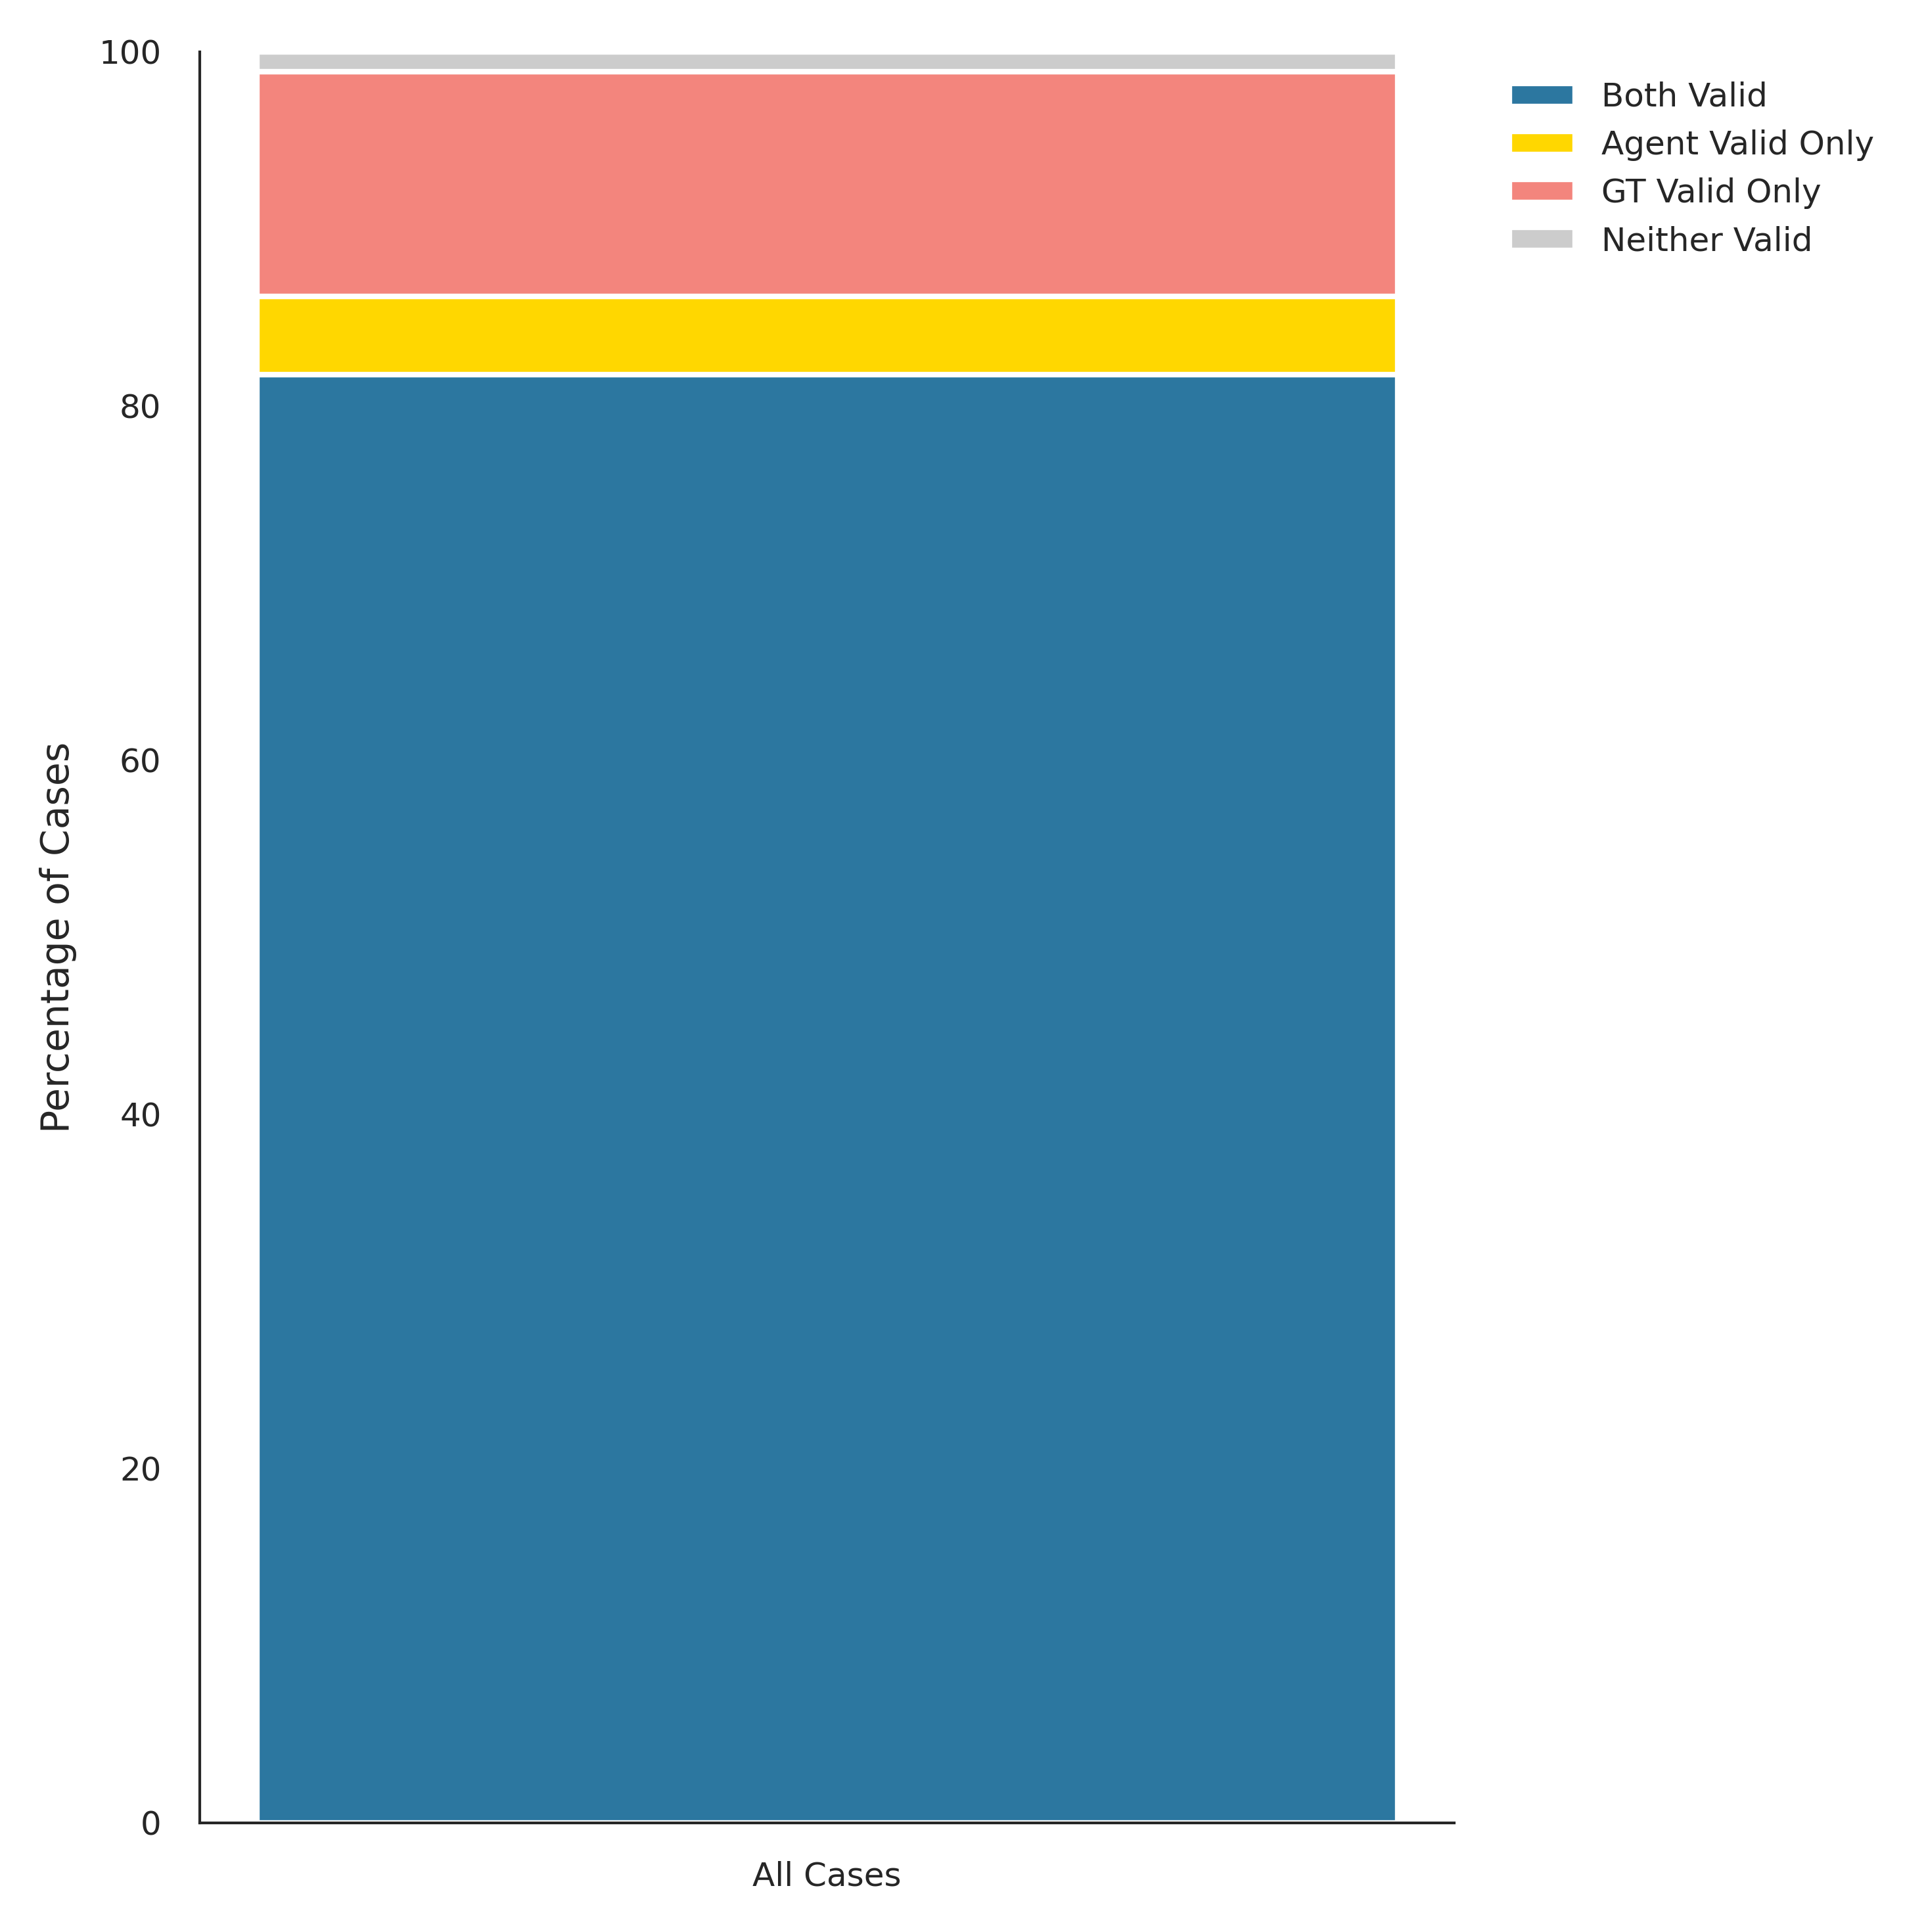

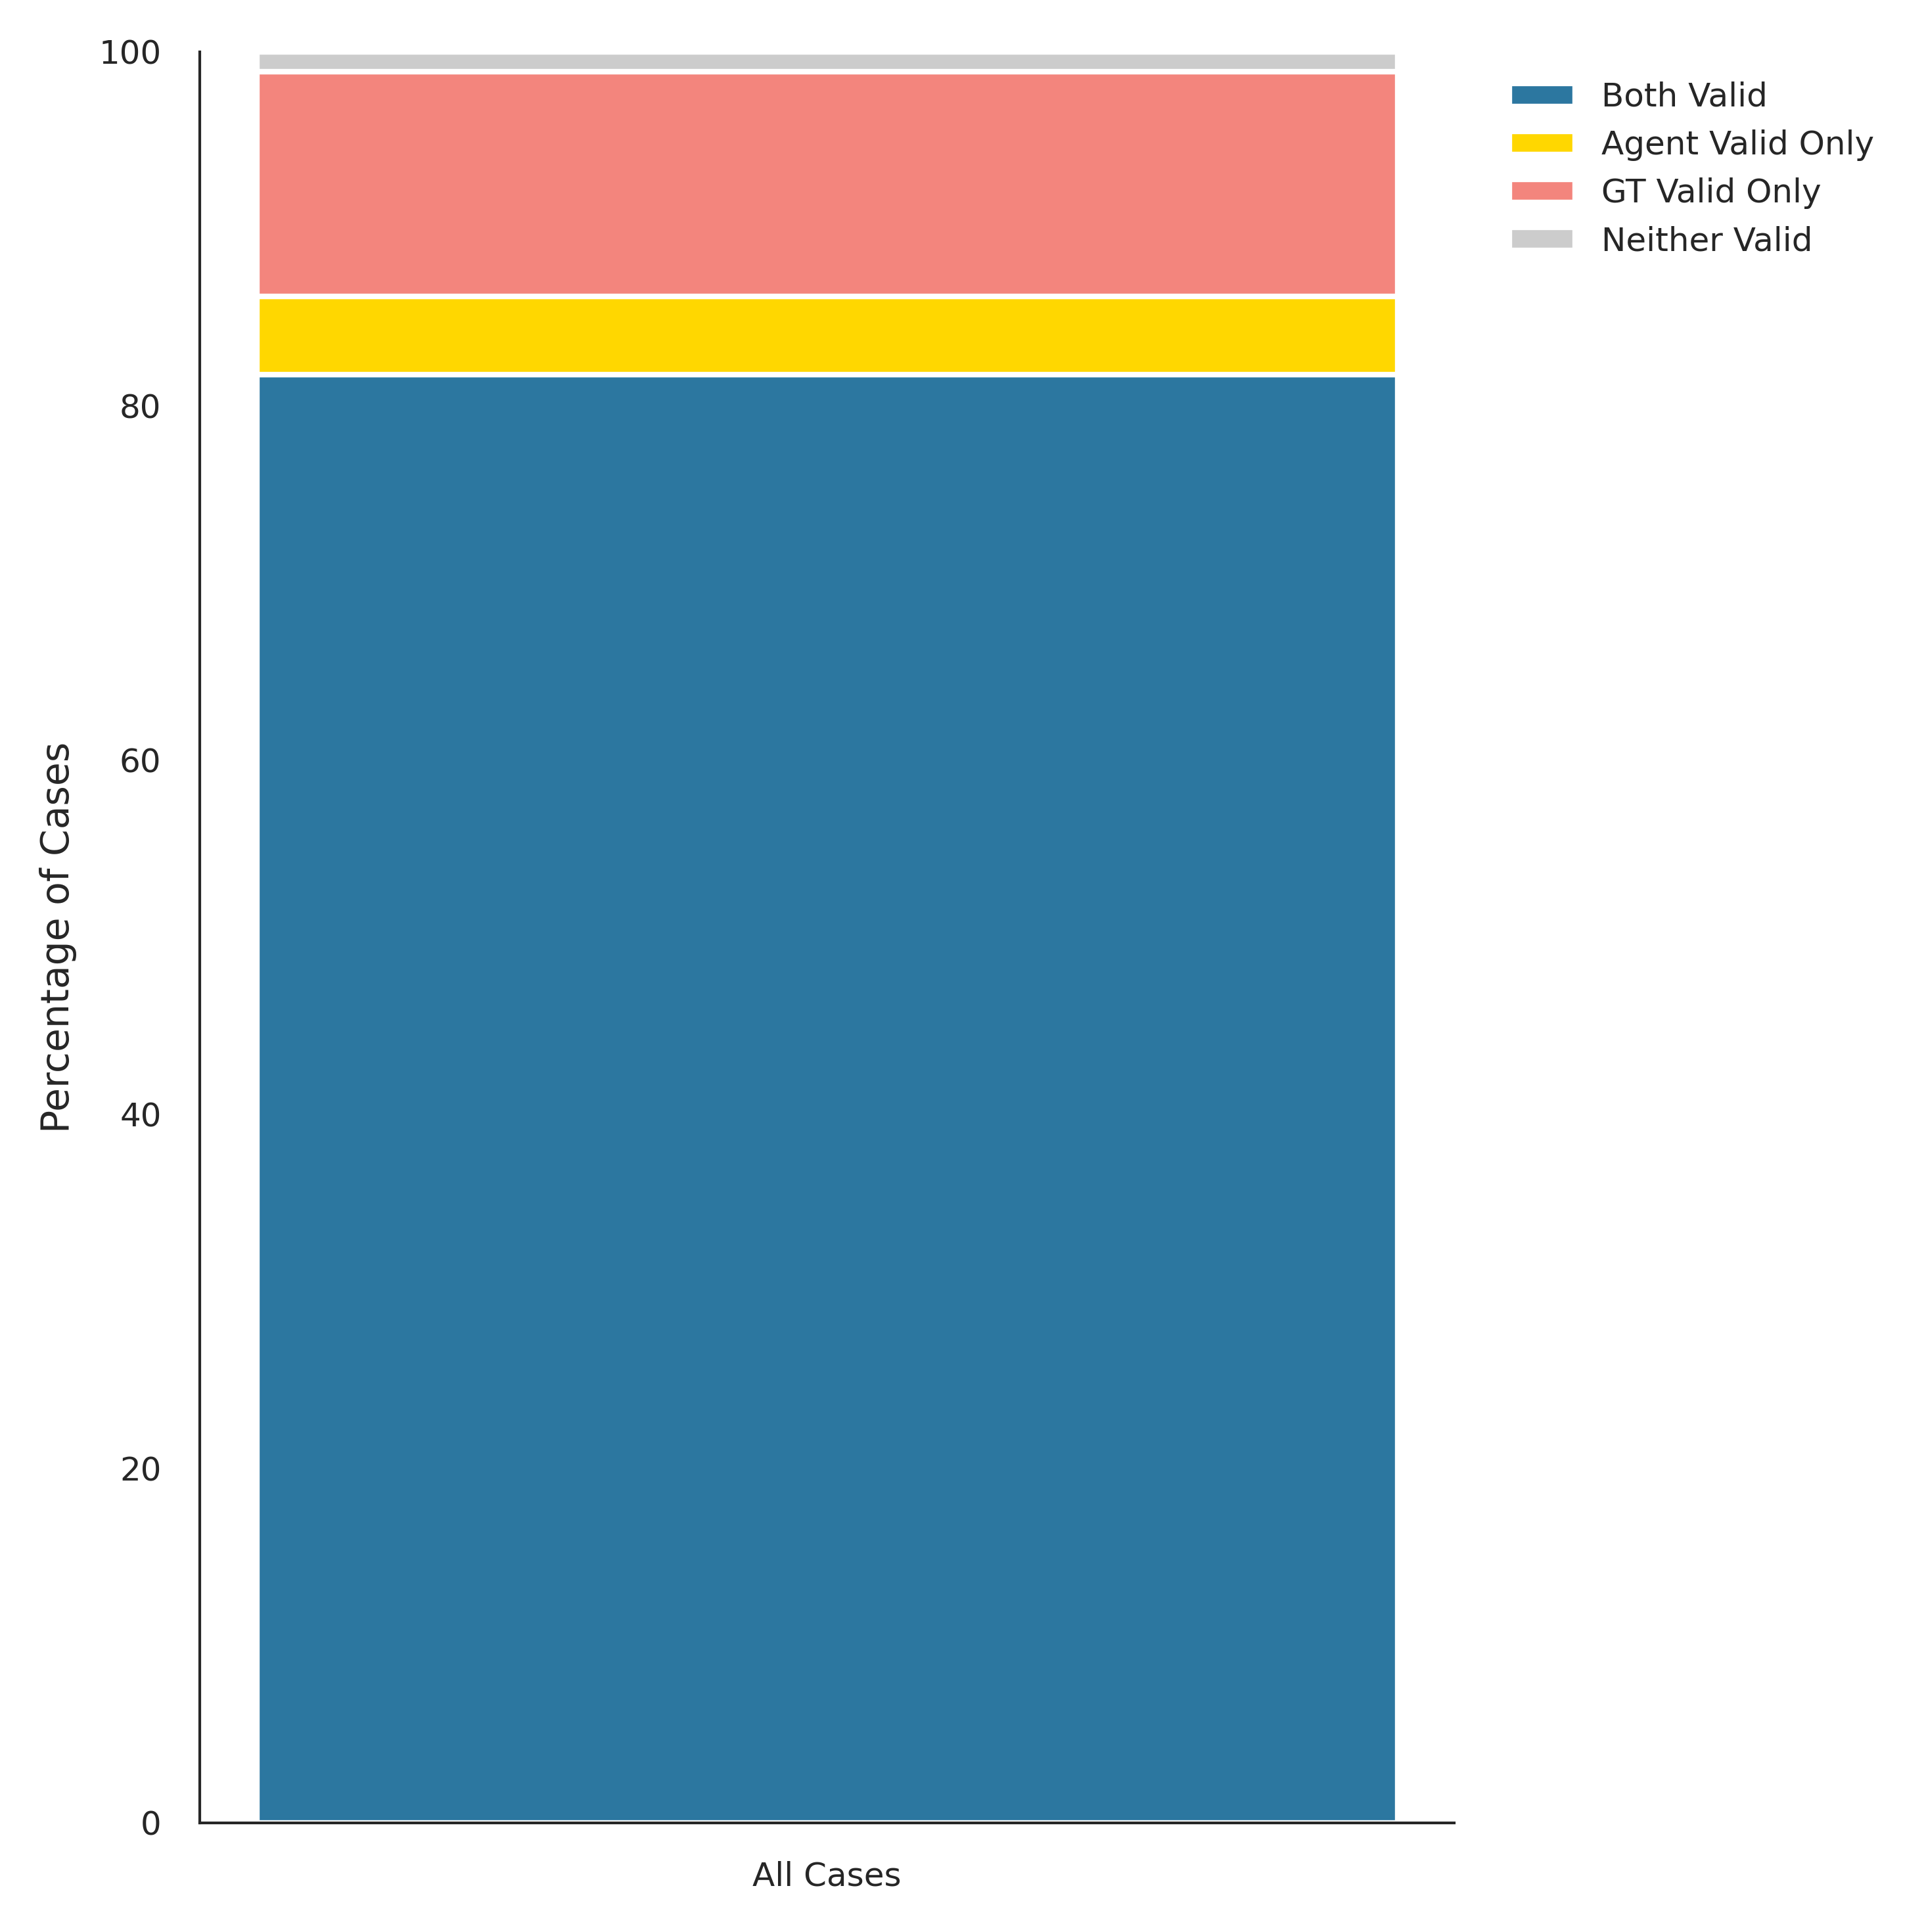

In [10]:
# Step 3. Create the stacked bar chart

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 3.1 Load data
all_case_level_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/all_rounds_case_level_consensus.csv"
)

plot_output_dir = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation"
)

plot_output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(all_case_level_file)
df.head()

# 3.2 Clean boolean columns
def clean_bool_2(val):
    if pd.isna(val):
        return pd.NA

    if isinstance(val, bool):
        return val

    val_str = str(val).strip().lower()

    if val_str in {"true", "1", "yes", "y", "t"}:
        return True
    if val_str in {"false", "0", "no", "n", "f"}:
        return False

    return pd.NA

df["ground_truth_consensus"] = df["ground_truth_consensus"].apply(clean_bool_2)
df["assistant_consensus"] = df["assistant_consensus"].apply(clean_bool_2)
df["agent_LLM_decision"] = df["agent_LLM_decision"].apply(clean_bool_2)


# 3.3 Build / verify outcome category

df["consensus_category"] = df.apply(assign_consensus_category, axis=1)

category_order = [
    "Both Valid",
    "Agent Valid Only",
    "GT Valid Only",
    "Neither Valid",
]

df["consensus_category"] = pd.Categorical(
    df["consensus_category"],
    categories=category_order,
    ordered=True,
)

df["consensus_category"].value_counts(dropna=False)

# 3.4 Overall stacked bar data
overall_counts = (
    df["consensus_category"]
    .value_counts(normalize=True)
    .reindex(category_order)
    .fillna(0) * 100
)

overall_counts

# 3.5 Plot overall stacked bar
colors = {
    "Both Valid": "#2c77a0",
    "Agent Valid Only": "#FFD700",
    "GT Valid Only": "#F3857D",
    "Neither Valid": "#cccccc",
}

fig, ax = plt.subplots(figsize=(5, 5), dpi=600)

bottom = 0
for category in category_order:
    value = overall_counts[category]
    ax.bar(
        ["All Cases"],
        [value],
        bottom=bottom,
        color=colors[category],
        edgecolor="white",
        label=category,
    )
    bottom += value

ax.set_ylabel("Percentage of Cases")
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


# 3.6 Save overall stacked bar

fig, ax = plt.subplots(figsize=(5, 5), dpi=600)

bottom = 0
for category in category_order:
    value = overall_counts[category]
    ax.bar(
        ["All Cases"],
        [value],
        bottom=bottom,
        color=colors[category],
        edgecolor="white",
        label=category,
    )
    bottom += value

ax.set_ylabel("Percentage of Cases")
ax.set_ylim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(plot_output_dir / "all_rounds_phase2_stacked_bar.svg", bbox_inches="tight", dpi=600)
plt.savefig(plot_output_dir / "all_rounds_phase2_stacked_bar.png", bbox_inches="tight", dpi=600)
plt.show()





Cases used for reliability analysis: 181
Raw agreement: 0.9227
TP: 149
TN: 18
FP: 7
FN: 7
Cohen's kappa: 0.6751
Gwet's AC1: 0.8985
PABAK: 0.8453
reliability_summary
    n_cases  raw_agreement  cohens_kappa  gwets_ac1     pabak  tp_both_valid  \
0      181       0.922652      0.675128   0.898482  0.845304            149   

   tn_both_invalid  fp_llm_only_valid  fn_physician_only_valid  
0               18                  7                        7  
Across 181 cases, the automated LLM-based judge achieved 92.3% raw agreement with physician consensus on assistant-diagnosis validity (Cohen's kappa = 0.675, Gwet's AC1 = 0.898, PABAK = 0.845).
Confusion matrix counts were: TP=149, TN=18, FP=7, FN=7.
Saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/llm_vs_physician_reliability_summary.csv


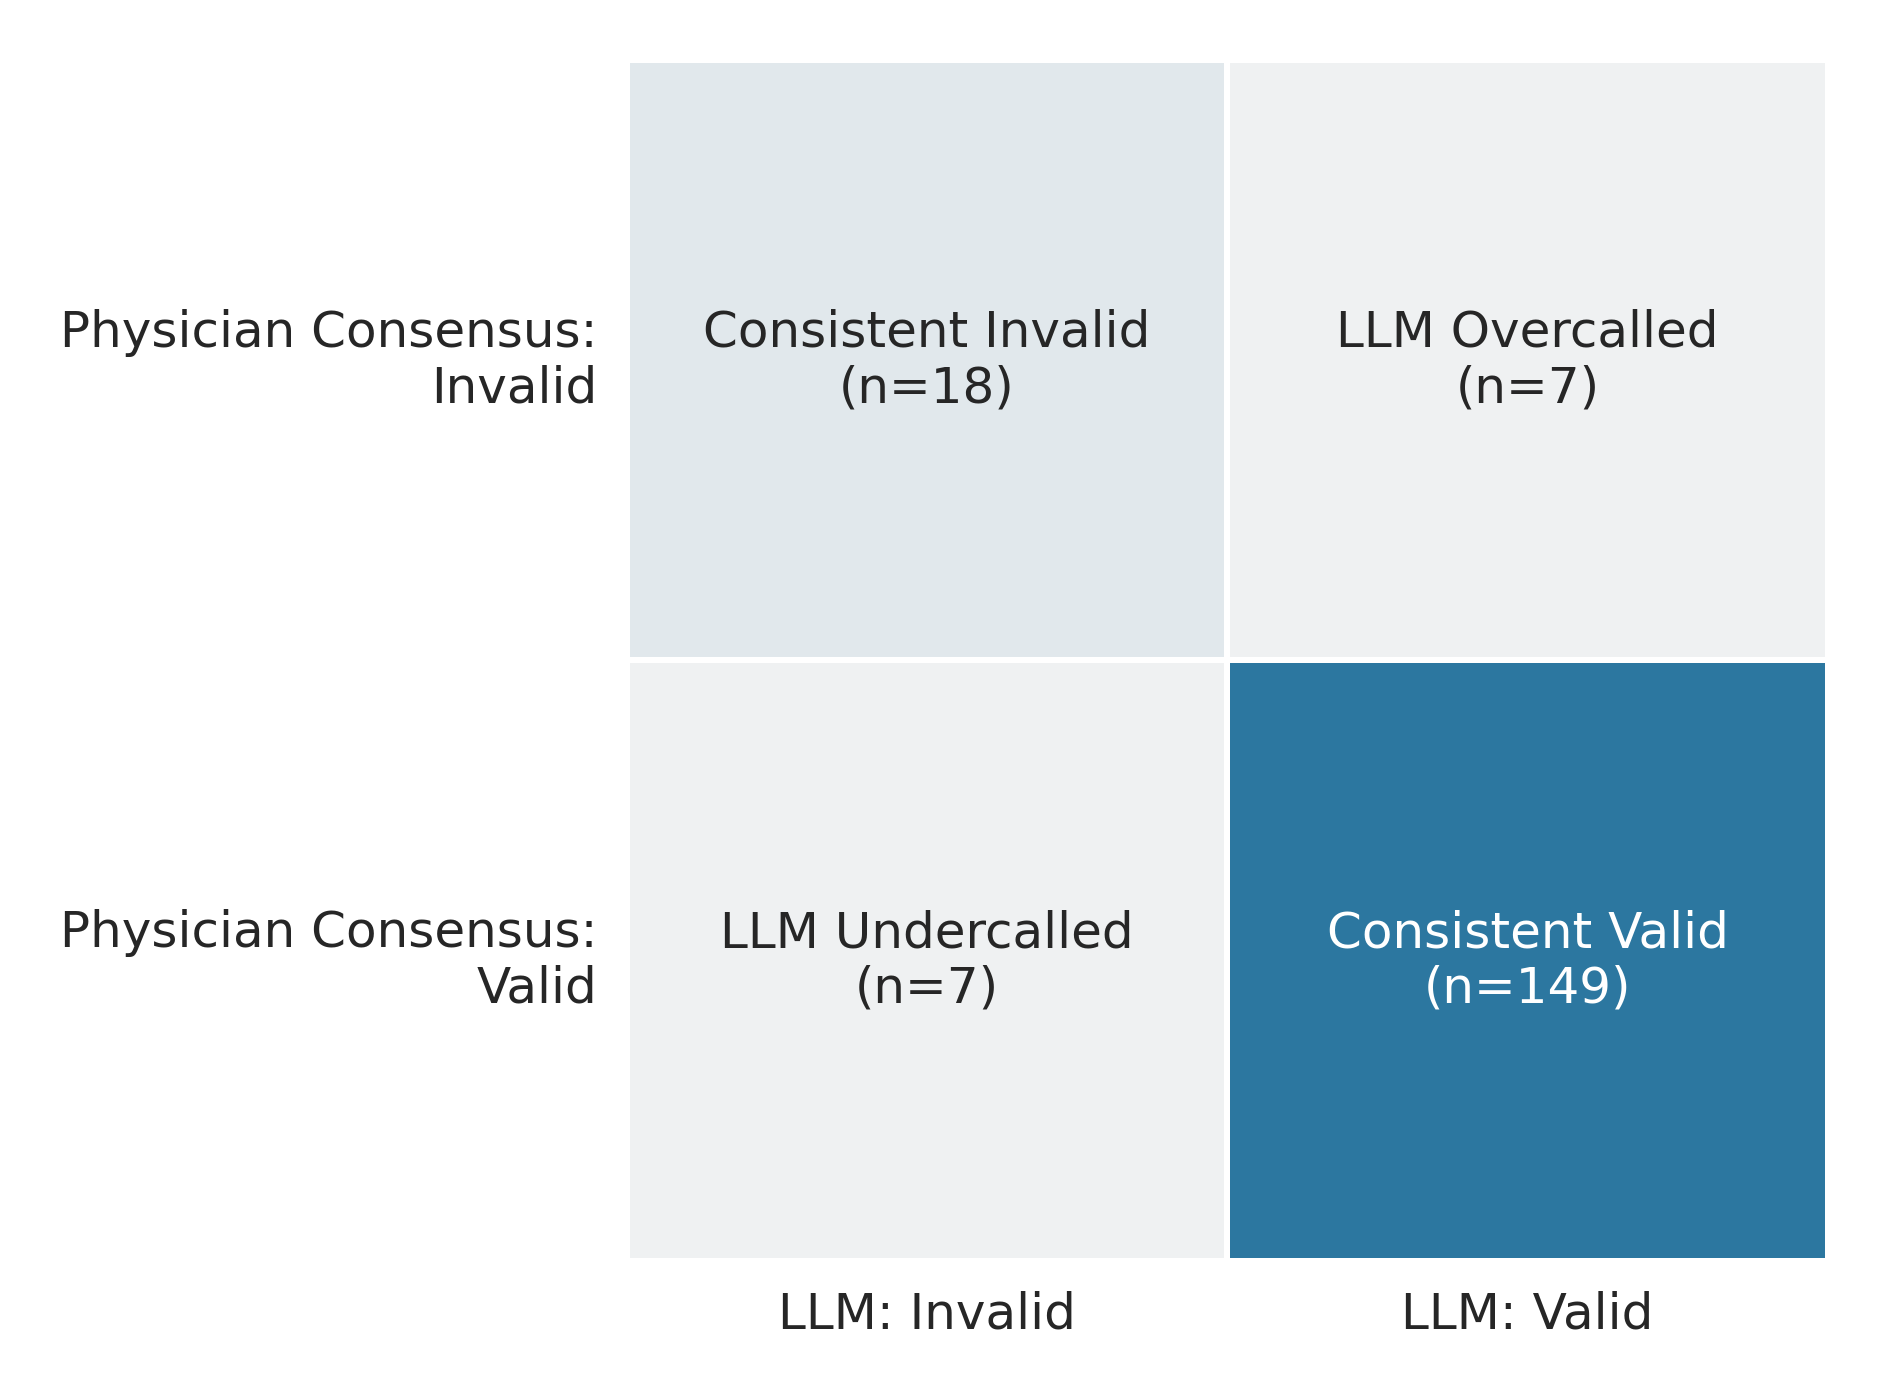

In [11]:
# Step 4. Perform LLM-vs-physician reliability analysis

'''
这里比较的是：
assistant_consensus
vs
agent_LLM_decision
'''

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 4.1 Keep valid rows only
reliability_df = df[
    df["assistant_consensus"].notna() &
    df["agent_LLM_decision"].notna()
].copy()

print("Cases used for reliability analysis:", len(reliability_df))
reliability_df.head()

# 4.2 Compute raw agreement and confusion matrix counts
y_human = reliability_df["assistant_consensus"].astype(bool)
y_llm = reliability_df["agent_LLM_decision"].astype(bool)

raw_agreement = (y_human == y_llm).mean()

tp = int(((y_human == True) & (y_llm == True)).sum())
tn = int(((y_human == False) & (y_llm == False)).sum())
fp = int(((y_human == False) & (y_llm == True)).sum())
fn = int(((y_human == True) & (y_llm == False)).sum())

print("Raw agreement:", round(raw_agreement, 4))
print("TP:", tp)
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)

# 4.3 Compute Cohen's kappa, Gwet's AC1, PABAK
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_human, y_llm)

p1_yes = y_human.mean()
p2_yes = y_llm.mean()
p_yes = (p1_yes + p2_yes) / 2
p_no = 1 - p_yes

pe_ac1 = 2 * p_yes * p_no
ac1 = (raw_agreement - pe_ac1) / (1 - pe_ac1) if (1 - pe_ac1) != 0 else np.nan

pabak = 2 * raw_agreement - 1

print("Cohen's kappa:", round(kappa, 4))
print("Gwet's AC1:", round(ac1, 4))
print("PABAK:", round(pabak, 4))

# 4.4 Summary table
reliability_summary = pd.DataFrame([
    {
        "n_cases": len(reliability_df),
        "raw_agreement": raw_agreement,
        "cohens_kappa": kappa,
        "gwets_ac1": ac1,
        "pabak": pabak,
        "tp_both_valid": tp,
        "tn_both_invalid": tn,
        "fp_llm_only_valid": fp,
        "fn_physician_only_valid": fn,
    }
])

print("reliability_summary\n", reliability_summary)

# 4.5 Manuscript-friendly printout
print(
    f"Across {len(reliability_df)} cases, the automated LLM-based judge achieved "
    f"{raw_agreement:.1%} raw agreement with physician consensus on assistant-diagnosis validity "
    f"(Cohen's kappa = {kappa:.3f}, Gwet's AC1 = {ac1:.3f}, PABAK = {pabak:.3f})."
)
print(
    f"Confusion matrix counts were: TP={tp}, TN={tn}, FP={fp}, FN={fn}."
)

# 4.6 Save reliability summary
reliability_output_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/llm_vs_physician_reliability_summary.csv"
)

reliability_summary.to_csv(reliability_output_file, index=False, encoding="utf-8-sig")
print(f"Saved to: {reliability_output_file}")

# Step 4.7 Plot confusion matrix heatmap
# Assumes you already computed:
# tp, tn, fp, fn

sns.set_style("white")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
    "axes.linewidth": 0.5,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

cm = np.array([
    [tn, fp],
    [fn, tp]
])

annot_text = np.array([
    [f"Consistent Invalid\n(n={tn})", f"LLM Overcalled\n(n={fp})"],
    [f"LLM Undercalled\n(n={fn})", f"Consistent Valid\n(n={tp})"]
])

#(4.4, 3.4) #(3.8, 3.0)
fig, ax = plt.subplots(figsize=(2.8, 2.6), dpi=600)

sns.heatmap(
    cm,
    annot=annot_text,
    fmt="",
    cmap=sns.light_palette("#2c77a0", as_cmap=True),
    cbar=False,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"fontsize": 6, "ha": "center", "va": "center"}
)

ax.set_xticklabels(
    ["LLM: Invalid", "LLM: Valid"],
    rotation=0
)
ax.set_yticklabels(
    ["Physician Consensus:\nInvalid", "Physician Consensus:\nValid"],
    rotation=0
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(length=0)
# ax.set_title("LLM vs Physician Confusion Matrix", loc="left", fontsize=12)

for spine in ax.spines.values():
    spine.set_visible(False)

plt.savefig(plot_output_dir / "Judge_ConfusionMatrix.svg", bbox_inches="tight")
plt.savefig(plot_output_dir / "Judge_ConfusionMatrix.pdf", bbox_inches="tight")
plt.savefig(plot_output_dir / "Judge_ConfusionMatrix.png", bbox_inches="tight", dpi=600)
plt.show()




/tmp/ipykernel_76886/4110056906.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["disease", "consensus_category"])


by_disease_counts
 consensus_category  Both Valid  GT Valid Only  Agent Valid Only  Neither Valid
disease                                                                       
appendicitis                29              1                 0              0
cholecystitis               24              2                 0              0
diverticulitis              24              0                 3              0
pancreatitis                24              2                 0              0
pneumonia                   13             12                 3              1
pulmonary_embolism          17              1                 0              0
uti                         17              5                 2              1
by_disease_pct
 consensus_category  Both Valid  GT Valid Only  Agent Valid Only  Neither Valid
disease                                                                       
appendicitis         96.666667       3.333333          0.000000       0.000000
cholecystitis    

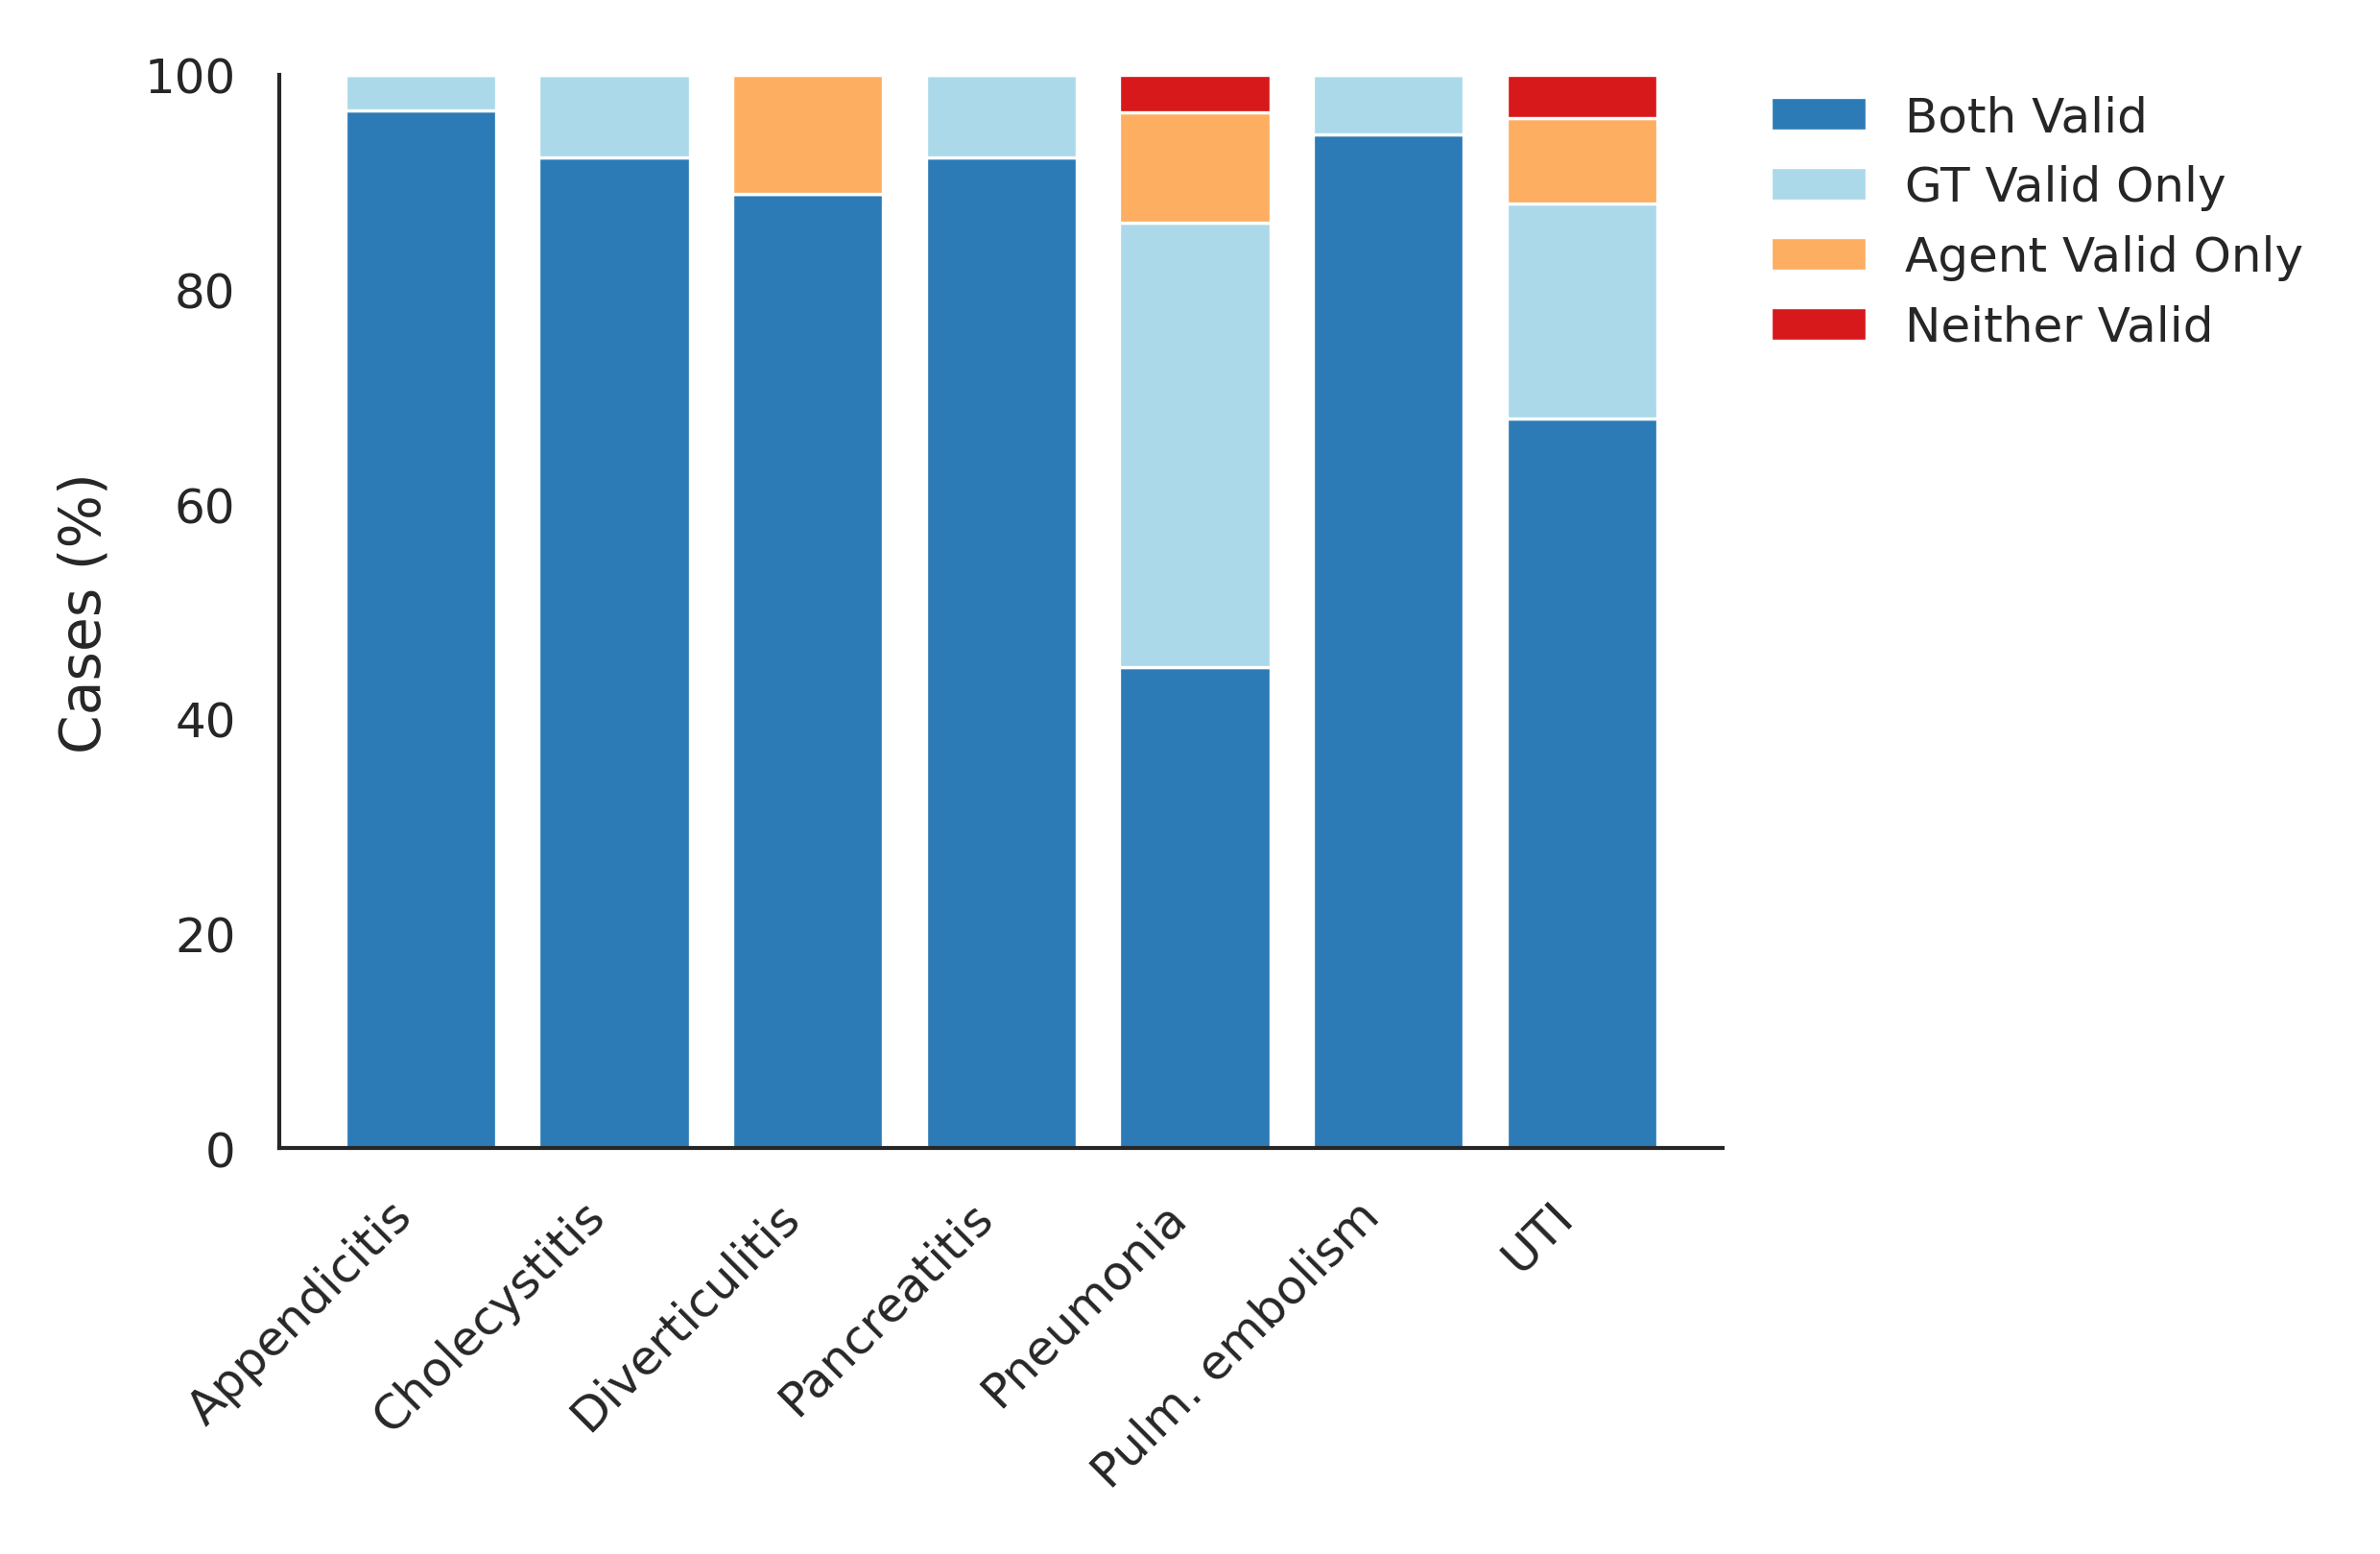

Saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/by_disease_outputs/by_disease_consensus_summary.csv


In [12]:
# Step 5. Perform by-disease analysis
# 5.1 by-disease stacked bar
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
    "axes.linewidth": 0.5,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# 5.1.1 Load data
all_case_level_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/all_rounds_case_level_consensus.csv"
)

output_dir = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/by_disease_outputs"
)
output_dir.mkdir(parents=True, exist_ok=True)

plot_output_dir = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation"
)

df = pd.read_csv(all_case_level_file)
df.head()

# 5.1.2 Clean columns
def clean_bool_3(val):
    if pd.isna(val):
        return pd.NA

    if isinstance(val, bool):
        return val

    val_str = str(val).strip().lower()

    if val_str in {"true", "1", "yes", "y", "t"}:
        return True
    if val_str in {"false", "0", "no", "n", "f"}:
        return False

    return pd.NA

df["ground_truth_consensus"] = df["ground_truth_consensus"].apply(clean_bool_3)
df["assistant_consensus"] = df["assistant_consensus"].apply(clean_bool_3)
df["agent_LLM_decision"] = df["agent_LLM_decision"].apply(clean_bool_3)

df["hadm_id"] = df["hadm_id"].astype(str).str.strip()
df["disease"] = df["disease"].astype(str).str.strip()

# 5.1.3 Build / verify case-level category
category_order = [
    "Both Valid",
    "GT Valid Only",
    "Agent Valid Only",
    "Neither Valid",
]

disease_display = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
    "pneumonia": "Pneumonia",
    "pulmonary_embolism": "Pulm. embolism",
    "uti": "UTI",
}

df["consensus_category"] = df.apply(assign_consensus_category, axis=1)
df["consensus_category"] = pd.Categorical(
    df["consensus_category"],
    categories=category_order,
    ordered=True,
)

df["consensus_category"].value_counts(dropna=False)

# 5.1.4 By-disease stacked bar data
by_disease_counts = (
    df.groupby(["disease", "consensus_category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=category_order, fill_value=0)
)

by_disease_pct = by_disease_counts.div(by_disease_counts.sum(axis=1), axis=0) * 100

print('by_disease_counts\n', by_disease_counts)

print('by_disease_pct\n', by_disease_pct)

# 5.1.5 Plot by-disease stacked bar
# colors = {
#     "Both Valid": "#354E6B", #"#2c7bb6", 
#     "GT Valid Only": "#4182A4", #"#abd9e9",
#     "Agent Valid Only": "#F0C2A2", #"#fdae61",
#     "Neither Valid": "#A64036", #"#d7191c",
# }
colors = {
    "Both Valid": "#2c7bb6", 
    "GT Valid Only": "#abd9e9",
    "Agent Valid Only": "#fdae61",
    "Neither Valid": "#d7191c",
}

fig, ax = plt.subplots(figsize=(4.25, 2.8), dpi=600) # (8, 5)

bottom = np.zeros(len(by_disease_pct))
x = np.arange(len(by_disease_pct))

for category in category_order:
    values = by_disease_pct[category].values
    ax.bar(
        by_disease_pct.index,
        values,
        bottom=bottom,
        color=colors[category],
        edgecolor="white",
        linewidth=0.4,
        width=0.78,
        label=category,
    )
    bottom += values

ax.set_ylim(0, 100)
ax.set_ylabel("Cases (%)")
ax.set_xticks(x)
ax.set_xticklabels([disease_display[d] for d in by_disease_pct.index], rotation=45, ha="right")
# ax.set_xlabel("Disease")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# ax.tick_params(axis="x", rotation=45)
ax.tick_params(length=2, width=0.5)

ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, title=None,)

plt.tight_layout()
plt.savefig(plot_output_dir / "by_disease_all_rounds_phase2_stacked_bar.svg", bbox_inches="tight", dpi=600)
plt.savefig(plot_output_dir / "by_disease_all_rounds_phase2_stacked_bar.png", bbox_inches="tight", dpi=600)
plt.savefig(plot_output_dir / "by_disease_all_rounds_phase2_stacked_bar.pdf", bbox_inches="tight", dpi=600)
plt.show()

# 5.1.6 Save by-disease stacked-bar table
by_disease_summary = by_disease_counts.copy()
by_disease_summary.columns = [f"{c}_count" for c in by_disease_summary.columns]

for category in category_order:
    by_disease_summary[f"{category}_pct"] = by_disease_pct[category]

by_disease_summary = by_disease_summary.reset_index()
by_disease_summary

by_disease_summary_file = output_dir / "by_disease_consensus_summary.csv"
by_disease_summary.to_csv(by_disease_summary_file, index=False, encoding="utf-8-sig")
print(f"Saved to: {by_disease_summary_file}")



Total cases for reliability: 181
by_disease_reliability
               disease  n_cases  raw_agreement  cohens_kappa  gwets_ac1  \
0        appendicitis     30.0       1.000000      1.000000   1.000000   
1       cholecystitis     26.0       0.961538      0.779661   0.953447   
2      diverticulitis     27.0       0.962963      0.000000   0.961566   
3        pancreatitis     26.0       1.000000      1.000000   1.000000   
4           pneumonia     29.0       0.724138      0.442308   0.454118   
5  pulmonary_embolism     18.0       0.944444      0.640000   0.934426   
6                 uti     25.0       0.880000      0.603175   0.829739   

      pabak    tp   tn   fp   fn  human_positive_rate  llm_positive_rate  
0  1.000000  29.0  1.0  0.0  0.0             0.966667           0.966667  
1  0.923077  23.0  2.0  0.0  1.0             0.923077           0.884615  
2  0.925926  26.0  0.0  0.0  1.0             1.000000           0.962963  
3  1.000000  24.0  2.0  0.0  0.0             0.923

/tmp/ipykernel_76886/2068274375.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_reliability)


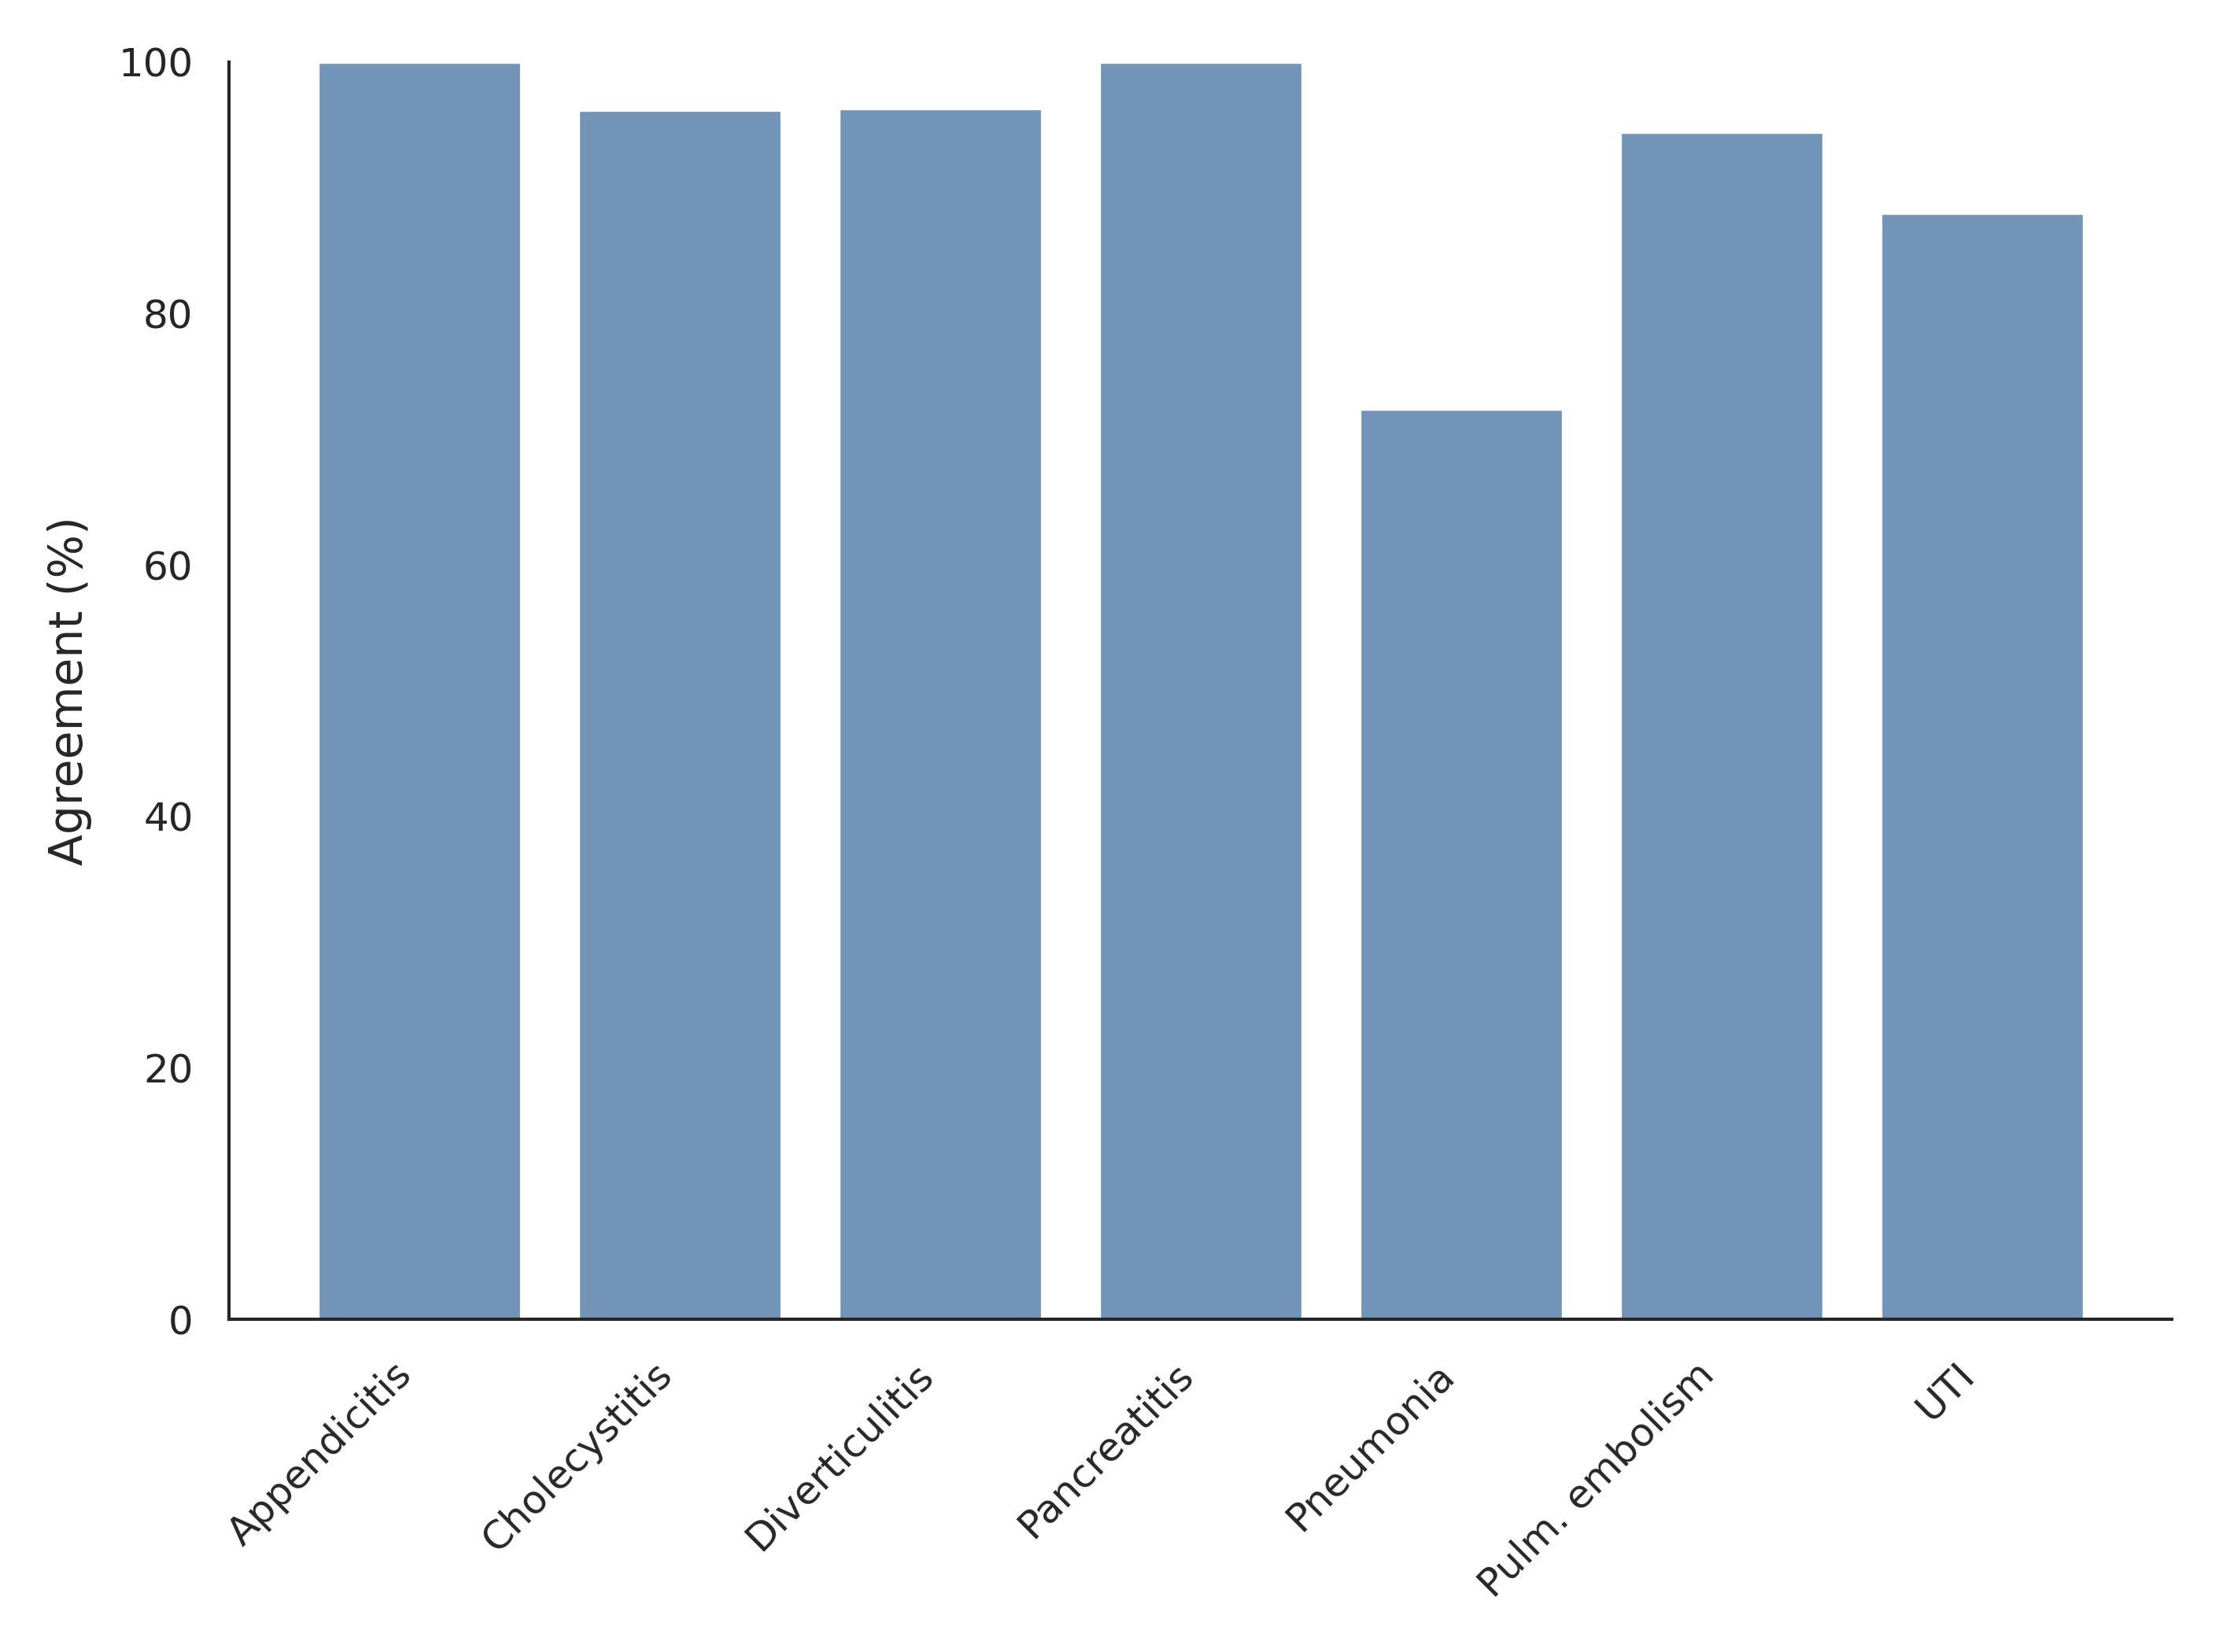

,disease,Neither Valid_count,Neither Valid_pct
6,uti,1,4.000000
4,pneumonia,1,3.448276
0,appendicitis,0,0.000000
2,diverticulitis,0,0.000000
1,cholecystitis,0,0.000000
3,pancreatitis,0,0.000000
5,pulmonary_embolism,0,0.000000


In [5]:
# 5.2 By-disease LLM-vs-physician reliability
'''
这里比较：

assistant_consensus
vs
agent_LLM_decision
按 disease 分层。
'''

# 5.2.1 Prepare valid rows
reliability_df = df[
    df["assistant_consensus"].notna() &
    df["agent_LLM_decision"].notna()
].copy()

print("Total cases for reliability:", len(reliability_df))
reliability_df.head()

# 5.2.2 Define summary function

def summarize_reliability(subdf):
    y_human = subdf["assistant_consensus"].astype(bool)
    y_llm = subdf["agent_LLM_decision"].astype(bool)

    raw_agreement = (y_human == y_llm).mean()

    tp = int(((y_human == True) & (y_llm == True)).sum())
    tn = int(((y_human == False) & (y_llm == False)).sum())
    fp = int(((y_human == False) & (y_llm == True)).sum())
    fn = int(((y_human == True) & (y_llm == False)).sum())

    try:
        kappa = cohen_kappa_score(y_human, y_llm)
    except Exception:
        kappa = np.nan

    p1_yes = y_human.mean()
    p2_yes = y_llm.mean()
    p_yes = (p1_yes + p2_yes) / 2
    p_no = 1 - p_yes

    pe_ac1 = 2 * p_yes * p_no
    ac1 = (raw_agreement - pe_ac1) / (1 - pe_ac1) if (1 - pe_ac1) != 0 else np.nan

    pabak = 2 * raw_agreement - 1

    return pd.Series({
        "n_cases": len(subdf),
        "raw_agreement": raw_agreement,
        "cohens_kappa": kappa,
        "gwets_ac1": ac1,
        "pabak": pabak,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "human_positive_rate": y_human.mean(),
        "llm_positive_rate": y_llm.mean(),
    })

# 5.2.3 Run by-disease reliability
by_disease_reliability = (
    reliability_df.groupby("disease")
    .apply(summarize_reliability)
    .reset_index()
    # .sort_values("n_cases", ascending=False)
)

print('by_disease_reliability\n', by_disease_reliability)

# 5.2.4 Save by-disease reliability table
by_disease_reliability_file = output_dir / "by_disease_llm_vs_physician_reliability.csv"
by_disease_reliability.to_csv(by_disease_reliability_file, index=False, encoding="utf-8-sig")
print(f"Saved to: {by_disease_reliability_file}")

# 5.2.5 Plot and save raw agreement plot
fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=600) #(7, 4.5)

x = np.arange(len(by_disease_reliability))

# plot_df = by_disease_reliability.sort_values("raw_agreement", ascending=False)
plot_df = by_disease_reliability
bars = ax.bar(
    x, #plot_df["disease"],
    plot_df["raw_agreement"] * 100,
    color="#7194B8", #"#2c77a0",
    edgecolor="white",
    linewidth=0.4,
    width=0.78,
    )

ax.set_ylabel("Agreement (%)")
ax.set_ylim(0, 100)
ax.set_xticks(x)
ax.set_xticklabels([disease_display[d] for d in by_disease_reliability["disease"]], rotation=45, ha="right")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(length=2, width=0.5)

# Optional: add n on top of bars
# for bar, n in zip(bars, by_disease_reliability["n_cases"]):
#     ax.text(
#         bar.get_x() + bar.get_width() / 2,
#         bar.get_height() + 1.5,
#         f"n={int(n)}",
#         ha="center",
#         va="bottom",
#         fontsize=5.5,
#         color="#444444",
#     )

plt.tight_layout()
plt.savefig(plot_output_dir / "by_disease_llm_agreement_mainpanel.svg", bbox_inches="tight")
plt.savefig(plot_output_dir / "by_disease_llm_agreement_mainpanel.pdf", bbox_inches="tight")
plt.savefig(plot_output_dir / "by_disease_llm_agreement_mainpanel.png", bbox_inches="tight", dpi=600)
plt.show()

# 5.2.7 Small sanity-check tables
# Diseases with the most “Agent Valid Only”

by_disease_summary[
    ["disease", "Agent Valid Only_count", "Agent Valid Only_pct"]
].sort_values("Agent Valid Only_pct", ascending=False)

# Diseases with the most “Neither Valid”

by_disease_summary[
    ["disease", "Neither Valid_count", "Neither Valid_pct"]
].sort_values("Neither Valid_pct", ascending=False)




In [6]:
# Step 6. Create the inter-rater agreement summary
# 6.1 Load rating-level data
from pathlib import Path
from itertools import combinations

import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score

round1_rating_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round1/round1_rating_level.csv"
)

round2_rating_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round2/decoded_physician_results_round2.csv"
)

output_dir = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/inter_rater_outputs"
)
output_dir.mkdir(parents=True, exist_ok=True)

round1_rating = pd.read_csv(round1_rating_file)
round2_rating = pd.read_csv(round2_rating_file)

round1_rating.head(), round2_rating.head()

# 6.2 Clean boolean columns
def clean_bool_4(val):
    if pd.isna(val):
        return pd.NA

    if isinstance(val, bool):
        return val

    val_str = str(val).strip().lower()

    if val_str in {"true", "1", "yes", "y", "t"}:
        return True
    if val_str in {"false", "0", "no", "n", "f"}:
        return False
    if val_str == "":
        return pd.NA

    return pd.NA

for df in [round1_rating, round2_rating]:
    df["ground_truth_is_true"] = df["ground_truth_is_true"].apply(clean_bool_4)
    df["assistant_diagnosis_is_true"] = df["assistant_diagnosis_is_true"].apply(clean_bool_4)
    df["hadm_id"] = df["hadm_id"].astype(str).str.strip()

# 6.3 Helper functions
def compute_pair_metrics(r1: pd.Series, r2: pd.Series):
    valid = r1.notna() & r2.notna()
    r1 = r1[valid].astype(bool)
    r2 = r2[valid].astype(bool)

    n = len(r1)
    if n == 0:
        return {
            "n_cases": 0,
            "raw_agreement": np.nan,
            "cohens_kappa": np.nan,
            "gwets_ac1": np.nan,
            "pabak": np.nan,
            "positive_agreement": np.nan,
            "negative_agreement": np.nan,
            "both_true": np.nan,
            "both_false": np.nan,
            "r1_true_r2_false": np.nan,
            "r1_false_r2_true": np.nan,
        }

    both_true = int(((r1 == True) & (r2 == True)).sum())
    both_false = int(((r1 == False) & (r2 == False)).sum())
    r1_true_r2_false = int(((r1 == True) & (r2 == False)).sum())
    r1_false_r2_true = int(((r1 == False) & (r2 == True)).sum())

    raw_agreement = (r1 == r2).mean()

    try:
        kappa = cohen_kappa_score(r1, r2)
    except Exception:
        kappa = np.nan

    # Gwet's AC1
    p1_yes = r1.mean()
    p2_yes = r2.mean()
    p_yes = (p1_yes + p2_yes) / 2
    p_no = 1 - p_yes
    pe_ac1 = 2 * p_yes * p_no
    ac1 = (raw_agreement - pe_ac1) / (1 - pe_ac1) if (1 - pe_ac1) != 0 else np.nan

    # PABAK
    pabak = 2 * raw_agreement - 1

    # Positive agreement / Negative agreement
    pos_denom = (2 * both_true + r1_true_r2_false + r1_false_r2_true)
    neg_denom = (2 * both_false + r1_true_r2_false + r1_false_r2_true)

    positive_agreement = (2 * both_true / pos_denom) if pos_denom > 0 else np.nan
    negative_agreement = (2 * both_false / neg_denom) if neg_denom > 0 else np.nan

    return {
        "n_cases": n,
        "raw_agreement": raw_agreement,
        "cohens_kappa": kappa,
        "gwets_ac1": ac1,
        "pabak": pabak,
        "positive_agreement": positive_agreement,
        "negative_agreement": negative_agreement,
        "both_true": both_true,
        "both_false": both_false,
        "r1_true_r2_false": r1_true_r2_false,
        "r1_false_r2_true": r1_false_r2_true,
    }

def compute_full_pattern_agreement(df1: pd.DataFrame, df2: pd.DataFrame) -> dict:
    merged = df1.merge(
        df2,
        on="hadm_id",
        suffixes=("_1", "_2")
    )

    valid = (
        merged["ground_truth_is_true_1"].notna() &
        merged["ground_truth_is_true_2"].notna() &
        merged["assistant_diagnosis_is_true_1"].notna() &
        merged["assistant_diagnosis_is_true_2"].notna()
    )

    merged = merged[valid].copy()
    n = len(merged)

    if n == 0:
        return {
            "n_cases": 0,
            "full_pattern_agreement": np.nan
        }

    full_agreement = (
        (merged["ground_truth_is_true_1"].astype(bool) == merged["ground_truth_is_true_2"].astype(bool)) &
        (merged["assistant_diagnosis_is_true_1"].astype(bool) == merged["assistant_diagnosis_is_true_2"].astype(bool))
    ).mean()

    return {
        "n_cases": n,
        "full_pattern_agreement": full_agreement
    }


# 6.4 Round 1 inter-rater agreement
# Include only the two primary physicians.

round1_primary = round1_rating[round1_rating["rater_role"] == "primary"].copy()

print(round1_primary["physician_name"].value_counts())

round1_physicians = sorted(round1_primary["physician_name"].dropna().unique())
round1_physicians

r1_name, r2_name = round1_physicians[0], round1_physicians[1]

r1_df = round1_primary[round1_primary["physician_name"] == r1_name][
    ["hadm_id", "ground_truth_is_true", "assistant_diagnosis_is_true"]
].copy()

r2_df = round1_primary[round1_primary["physician_name"] == r2_name][
    ["hadm_id", "ground_truth_is_true", "assistant_diagnosis_is_true"]
].copy()

round1_gt_metrics = compute_pair_metrics(
    r1_df.set_index("hadm_id")["ground_truth_is_true"],
    r2_df.set_index("hadm_id")["ground_truth_is_true"],
)

round1_asst_metrics = compute_pair_metrics(
    r1_df.set_index("hadm_id")["assistant_diagnosis_is_true"],
    r2_df.set_index("hadm_id")["assistant_diagnosis_is_true"],
)

round1_full_metrics = compute_full_pattern_agreement(r1_df, r2_df)

round1_summary = pd.DataFrame([
    {
        "round": "round1",
        "subset": "two_primary_physicians",
        "physician_1": r1_name,
        "physician_2": r2_name,
        "task": "ground_truth_validity",
        **round1_gt_metrics,
    },
    {
        "round": "round1",
        "subset": "two_primary_physicians",
        "physician_1": r1_name,
        "physician_2": r2_name,
        "task": "assistant_validity",
        **round1_asst_metrics,
    },
    {
        "round": "round1",
        "subset": "two_primary_physicians",
        "physician_1": r1_name,
        "physician_2": r2_name,
        "task": "full_pattern",
        **round1_full_metrics,
    },
])

round1_summary


physician_name
Julien    111
Xuewei    111
Name: count, dtype: int64


,round,subset,physician_1,physician_2,task,n_cases,raw_agreement,cohens_kappa,gwets_ac1,pabak,positive_agreement,negative_agreement,both_true,both_false,r1_true_r2_false,r1_false_r2_true,full_pattern_agreement
0,round1,two_primary_physicians,Julien,Xuewei,ground_truth_validity,111,0.963964,-0.013699,0.962642,0.927928,0.981651,0.000000,107.0,0.0,3.0,1.0,NaN
1,round1,two_primary_physicians,Julien,Xuewei,assistant_validity,111,0.936937,0.433260,0.929122,0.873874,0.966507,0.461538,101.0,3.0,1.0,6.0,NaN
2,round1,two_primary_physicians,Julien,Xuewei,full_pattern,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.918919


In [7]:
# 6.2 Round 2 inter-rater agreement
# Include only the x group, the shared overlapping subset of six physicians.


round2_x = round2_rating[round2_rating["case_group"] == "x"].copy()

print("Round 2 x-group rows:", len(round2_x))
print(round2_x["physician_name"].value_counts())
print("Unique x-group cases:", round2_x["hadm_id"].nunique())

# 6.2.1 pairwise agreement for all 6 physicians
round2_physicians = sorted(round2_x["physician_name"].dropna().unique())
round2_physicians


pairwise_rows = []

for p1, p2 in combinations(round2_physicians, 2):
    d1 = round2_x[round2_x["physician_name"] == p1][
        ["hadm_id", "ground_truth_is_true", "assistant_diagnosis_is_true"]
    ].copy()

    d2 = round2_x[round2_x["physician_name"] == p2][
        ["hadm_id", "ground_truth_is_true", "assistant_diagnosis_is_true"]
    ].copy()

    gt_metrics = compute_pair_metrics(
        d1.set_index("hadm_id")["ground_truth_is_true"],
        d2.set_index("hadm_id")["ground_truth_is_true"],
    )

    asst_metrics = compute_pair_metrics(
        d1.set_index("hadm_id")["assistant_diagnosis_is_true"],
        d2.set_index("hadm_id")["assistant_diagnosis_is_true"],
    )

    full_metrics = compute_full_pattern_agreement(d1, d2)

    pairwise_rows.append({
        "round": "round2",
        "subset": "x_group_pairwise",
        "physician_1": p1,
        "physician_2": p2,

        "gt_raw_agreement": gt_metrics["raw_agreement"],
        "gt_kappa": gt_metrics["cohens_kappa"],
        "gt_ac1": gt_metrics["gwets_ac1"],
        "gt_pabak": gt_metrics["pabak"],
        "gt_positive_agreement": gt_metrics["positive_agreement"],
        "gt_negative_agreement": gt_metrics["negative_agreement"],

        "assistant_raw_agreement": asst_metrics["raw_agreement"],
        "assistant_kappa": asst_metrics["cohens_kappa"],
        "assistant_ac1": asst_metrics["gwets_ac1"],
        "assistant_pabak": asst_metrics["pabak"],
        "assistant_positive_agreement": asst_metrics["positive_agreement"],
        "assistant_negative_agreement": asst_metrics["negative_agreement"],

        "full_pattern_agreement": full_metrics["full_pattern_agreement"],
        "n_cases_overlap": gt_metrics["n_cases"],
    })

round2_pairwise = pd.DataFrame(pairwise_rows)
round2_pairwise.head()


# 6.2.2 average pairwise summary
round2_pairwise_summary = pd.DataFrame([
    {
        "round": "round2",
        "subset": "x_group_all_6_physicians_pairwise_average",
        "n_physicians": len(round2_physicians),
        "n_cases": round2_x["hadm_id"].nunique(),

        "gt_raw_agreement_mean": round2_pairwise["gt_raw_agreement"].mean(),
        "gt_kappa_mean": round2_pairwise["gt_kappa"].mean(),
        "gt_ac1_mean": round2_pairwise["gt_ac1"].mean(),
        "gt_pabak_mean": round2_pairwise["gt_pabak"].mean(),
        "gt_positive_agreement_mean": round2_pairwise["gt_positive_agreement"].mean(),
        "gt_negative_agreement_mean": round2_pairwise["gt_negative_agreement"].mean(),

        "assistant_raw_agreement_mean": round2_pairwise["assistant_raw_agreement"].mean(),
        "assistant_kappa_mean": round2_pairwise["assistant_kappa"].mean(),
        "assistant_ac1_mean": round2_pairwise["assistant_ac1"].mean(),
        "assistant_pabak_mean": round2_pairwise["assistant_pabak"].mean(),
        "assistant_positive_agreement_mean": round2_pairwise["assistant_positive_agreement"].mean(),
        "assistant_negative_agreement_mean": round2_pairwise["assistant_negative_agreement"].mean(),

        "full_pattern_agreement_mean": round2_pairwise["full_pattern_agreement"].mean(),
    }
])

round2_pairwise_summary

# 6.2.3 Combine round1 + round2 summary
inter_rater_summary = pd.concat(
    [
        round1_summary,
        round2_pairwise_summary,
    ],
    ignore_index=True,
    sort=False,
)

inter_rater_summary


# 6.2.4 save outputs
round2_pairwise_file = output_dir / "round2_pairwise_inter_rater_agreement.csv"
summary_file = output_dir / "inter_rater_summary_all_rounds.csv"

round2_pairwise.to_csv(round2_pairwise_file, index=False, encoding="utf-8-sig")
inter_rater_summary.to_csv(summary_file, index=False, encoding="utf-8-sig")

print(f"Saved: {round2_pairwise_file}")
print(f"Saved: {summary_file}")

# 6.2.5 Simple manuscript-style printout
print("Round 1 inter-rater agreement:\n")
print(round1_summary)

print("\nRound 2 pairwise agreement average on X subset:\n")
print(round2_pairwise_summary)





Round 2 x-group rows: 120
physician_name
Catharina         20
Jan Clusmann      20
Julien Vibert     20
Xuewei Wu         20
Lino Möhrmann     20
Elena Möhrmann    20
Name: count, dtype: int64
Unique x-group cases: 20
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/inter_rater_outputs/round2_pairwise_inter_rater_agreement.csv
Saved: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/inter_rater_outputs/inter_rater_summary_all_rounds.csv
Round 1 inter-rater agreement:

    round                  subset physician_1 physician_2  \
0  round1  two_primary_physicians      Julien      Xuewei   
1  round1  two_primary_physicians      Julien      Xuewei   
2  round1  two_primary_physicians      Julien      Xuewei   

                    task  n_cases  raw_agreement  cohens_kappa  gwets_ac1  \
0  ground_truth_validity      111       0.963964     -0.013699   0.962642   
1     assistant_validity      111   

/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:897: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


In [8]:
# Step 7. Perform a small qualitative disagreement analysis

# 7.1 Load data
from pathlib import Path
import pandas as pd

all_case_level_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/all_rounds_case_level_consensus.csv"
)

round1_rating_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round1/round1_rating_level.csv"
)

round2_rating_file = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/round2/decoded_physician_results_round2.csv"
)

output_dir = Path(
    "/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/qualitative_outputs"
)
output_dir.mkdir(parents=True, exist_ok=True)

case_df = pd.read_csv(all_case_level_file)
round1_rating = pd.read_csv(round1_rating_file)
round2_rating = pd.read_csv(round2_rating_file)

# 7.2 Clean columns

def clean_bool_5(val):
    if pd.isna(val):
        return pd.NA

    if isinstance(val, bool):
        return val

    val_str = str(val).strip().lower()

    if val_str in {"true", "1", "yes", "y", "t"}:
        return True
    if val_str in {"false", "0", "no", "n", "f"}:
        return False

    return pd.NA

for df in [case_df, round1_rating, round2_rating]:
    if "hadm_id" in df.columns:
        df["hadm_id"] = df["hadm_id"].astype(str).str.strip()

for col in ["ground_truth_consensus", "assistant_consensus", "agent_LLM_decision"]:
    if col in case_df.columns:
        case_df[col] = case_df[col].apply(clean_bool_5)

for col in ["ground_truth_is_true", "assistant_diagnosis_is_true"]:
    if col in round1_rating.columns:
        round1_rating[col] = round1_rating[col].apply(clean_bool_5)
    if col in round2_rating.columns:
        round2_rating[col] = round2_rating[col].apply(clean_bool_5)

# 7.3 Build case-level disagreement flags
case_df["llm_vs_physician_disagreement"] = (
    case_df["assistant_consensus"].notna() &
    case_df["agent_LLM_decision"].notna() &
    (case_df["assistant_consensus"] != case_df["agent_LLM_decision"])
)

case_df["neither_valid_case"] = (
    (case_df["ground_truth_consensus"] == False) &
    (case_df["assistant_consensus"] == False)
)

case_df["agent_valid_only_case"] = (
    (case_df["ground_truth_consensus"] == False) &
    (case_df["assistant_consensus"] == True)
)

case_df.head()


# 7.4 Build round-level note table
'''
round1 大概率没有抽取note 列，round2 有 note。
所以这里主要从 round2 拉 note，但保留统一结构。
'''

round1_note_df = round1_rating.copy()
if "note" not in round1_note_df.columns:
    round1_note_df["note"] = ""

round1_note_df = round1_note_df[
    ["hadm_id", "physician_name", "ground_truth_is_true", "assistant_diagnosis_is_true", "note"]
].copy()
round1_note_df["round"] = "round1"


round2_note_df = round2_rating[
    ["hadm_id", "physician_name", "ground_truth_is_true", "assistant_diagnosis_is_true", "note"]
].copy()
round2_note_df["round"] = "round2"

all_notes_df = pd.concat([round1_note_df, round2_note_df], ignore_index=True)
all_notes_df["note"] = all_notes_df["note"].fillna("").astype(str).str.strip()

all_notes_df.head()

# 7.5 Count note availability
all_notes_df["has_note"] = all_notes_df["note"] != ""

print("Total rating rows with notes:", all_notes_df["has_note"].sum())
print("\nNotes by round:")
print(all_notes_df.groupby("round")["has_note"].sum())

print("\nNotes by physician:")
print(
    all_notes_df[all_notes_df["has_note"]]
    .groupby("physician_name")["has_note"]
    .sum()
    .sort_values(ascending=False)
)

# 7.6 Extract physician comments per case
# Combine multiple physician notes for the same case for easier review.
notes_per_case = (
    all_notes_df[all_notes_df["has_note"]]
    .groupby("hadm_id")
    .apply(
        lambda x: " | ".join(
            f"{row['physician_name']}: {row['note']}"
            for _, row in x.iterrows()
        )
    )
    .reset_index(name="physician_notes")
)

notes_per_case.head()

# 7.7 Merge notes into case-level table
qual_df = case_df.merge(notes_per_case, on="hadm_id", how="left")
qual_df["physician_notes"] = qual_df["physician_notes"].fillna("")

qual_df.head()


Total rating rows with notes: 69

Notes by round:
round
round1     0
round2    69
Name: has_note, dtype: int64

Notes by physician:
physician_name
Elena Möhrmann    45
Julien Vibert     12
Jan Clusmann       7
Lino Möhrmann      5
Name: has_note, dtype: int64


/tmp/ipykernel_76886/227194767.py:126: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,round,hadm_id,case_group,disease,ground_truth_text,assistant_diagnosis_text,ground_truth_consensus,assistant_consensus,consensus_category,agent_LLM_decision,...,primary_disagreement_any,case_in_primary_overlap,expected_n_raters,n_raters,ground_truth_votes_true,assistant_votes_true,llm_vs_physician_disagreement,neither_valid_case,agent_valid_only_case,physician_notes
0,round1,28132333,NaN,diverticulitis,Diverticulitis of colon (without mention of he...,Acute sigmoid diverticulitis with possible mic...,True,True,Both Valid,True,...,0.0,NaN,NaN,NaN,NaN,NaN,False,False,False,
1,round1,29238948,NaN,cholecystitis,Calculus of gallbladder with acute cholecystit...,Acute cholecystitis with gallstones,True,True,Both Valid,True,...,0.0,NaN,NaN,NaN,NaN,NaN,False,False,False,
2,round1,21976655,NaN,cholecystitis,Acute cholecystitis,Acute cholecystitis with gallstone in gallblad...,True,True,Both Valid,True,...,0.0,NaN,NaN,NaN,NaN,NaN,False,False,False,
3,round1,25395630,NaN,pulmonary_embolism,Other pulmonary embolism and infarction,Pulmonary embolism,True,True,Both Valid,True,...,0.0,NaN,NaN,NaN,NaN,NaN,False,False,False,
4,round1,29709207,NaN,cholecystitis,Calculus of gallbladder with acute cholecystit...,Acute cholecystitis,True,True,Both Valid,True,...,0.0,NaN,NaN,NaN,NaN,NaN,False,False,False,


In [9]:
# 7.8 Select interesting disagreement cases
'''
优先看三类：

LLM vs physician disagreement
Agent Valid Only
Neither Valid
有 physician notes 的 case 优先
'''

interesting_cases = qual_df[
    qual_df["llm_vs_physician_disagreement"] |
    qual_df["agent_valid_only_case"] |
    qual_df["neither_valid_case"] |
    (qual_df["physician_notes"] != "")
].copy()

print(interesting_cases.shape)


interesting_cases = interesting_cases[
    [
        "round",
        "hadm_id",
        "disease",
        "ground_truth_text",
        "assistant_diagnosis_text",
        "ground_truth_consensus",
        "assistant_consensus",
        "consensus_category",
        "agent_LLM_decision",
        "llm_vs_physician_disagreement",
        "physician_notes",
        "agent_valid_only_case",
        "neither_valid_case",

    ]
].sort_values(
    # by=["llm_vs_physician_disagreement", "disease", "hadm_id"],
    by=["disease", "hadm_id"],
    # ascending=[False, True, True]
    ascending=[True, True]
)


# 7.9 table for llm_vs_physician_disagreement_cases
llm_disagreement_cases = interesting_cases[
    (interesting_cases["llm_vs_physician_disagreement"])
].copy()

llm_disagreement_cases_output_file = output_dir / "llm_vs_physician_disagreement_cases.csv"
llm_disagreement_cases.to_csv(llm_disagreement_cases_output_file, index=False, encoding="utf-8-sig")

print(f"Saved to: {llm_disagreement_cases_output_file}")

# 7.10 table for ground truth is invalid
gt_invalid_cases = interesting_cases[
    (interesting_cases["agent_valid_only_case"]) |
    (interesting_cases["neither_valid_case"])
].copy()

gt_invalid_output_file = output_dir / "gt_invalid_cases.csv"
gt_invalid_cases.to_csv(gt_invalid_output_file, index=False, encoding="utf-8-sig")

print(f"Saved to: {gt_invalid_output_file}")



(62, 24)
Saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/qualitative_outputs/llm_vs_physician_disagreement_cases.csv
Saved to: /mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/63/63.10/physician_evaluation/qualitative_outputs/gt_invalid_cases.csv
